<a href="https://colab.research.google.com/github/AIPI510/aipi510-fall24/blob/lecture-code/week_5_lecture_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 1 Project Exploratory Data Analysis Notebook
### AIPI 510: Sourcing for Data Analytics
### Caleb McNeill
### OpenF1 API

#### Purpose
This file explores the data in OpenF1 and documents the choices made for project analysis, relevant visualizations, and engineered features.

#### Calling OpenF1 API
The following cell imports all necessary packages and pulls data from the OpenF1 API to conduct analysis throughout the notebook.

In [2]:
"""Provide an overview of the combined 2023-2025 F1 season dataset."""

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

DATA_DIRECTORY = Path.cwd() / "data"
latest_csv = DATA_DIRECTORY / "f1_season_data_2023_2025_combined_20260922_114820_066553.csv"

if not latest_csv.is_file():
    raise FileNotFoundError(f"CSV file not found: {latest_csv.resolve()}")

df = pd.read_csv(latest_csv)

required_time_column = "Adjusted Overall Time (s)"
if required_time_column not in df.columns:
    raise ValueError(f"CSV is missing the required column: {required_time_column}")

df = df.dropna(subset=[required_time_column])

numeric_df = df.select_dtypes(include="number").drop(
    columns=[
        "Session Key",
        "Driver Number",
        "Position",
        "Overall Time (s)",
        "Lane Duration (s)",
        "Year",
    ],
    errors="ignore",
)

print("Data Structure")
print("---------------")
print(f"Dataset: {latest_csv.name}")
print(f"Dimensions: {numeric_df.shape}")
print(f"Data Types:\n{numeric_df.dtypes}")
print(f"Missing Values:\n{numeric_df.isnull().sum()}")

Data Structure
---------------
Dataset: f1_season_data_2023_2025_combined_20260922_114820_066553.csv
Dimensions: (924, 7)
Data Types:
Adjusted Overall Time (s)    float64
Max i1 Speed (km/h)          float64
Max i2 Speed (km/h)          float64
Max st Speed (km/h)          float64
Average i1 Speed (km/h)      float64
Average i2 Speed (km/h)      float64
Average st Speed (km/h)      float64
dtype: object
Missing Values:
Adjusted Overall Time (s)     0
Max i1 Speed (km/h)           0
Max i2 Speed (km/h)          13
Max st Speed (km/h)           0
Average i1 Speed (km/h)       0
Average i2 Speed (km/h)      13
Average st Speed (km/h)       0
dtype: int64


In [3]:
"""Find missing Max i2 Speed values and remove those rows from both dataframes."""
max_i2_speed_column = "Max i2 Speed (km/h)"
missing_max_i2_speed = df[max_i2_speed_column].isna()

print(f"Rows with missing {max_i2_speed_column}:")
print(df.loc[missing_max_i2_speed])
print(f"Missing Max i2 Speed rows removed: {missing_max_i2_speed.sum()}")

valid_max_i2_speed = ~missing_max_i2_speed
df = df.loc[valid_max_i2_speed].copy()
numeric_df = numeric_df.loc[numeric_df.index.intersection(df.index)].copy()

print(f"Updated df dimensions: {df.shape}")
print(f"Updated numeric_df dimensions: {numeric_df.shape}")

Rows with missing Max i2 Speed (km/h):
      Session Key  Driver Number           Driver             Team  Position  \
1037         9858              1   Max VERSTAPPEN  Red Bull Racing       1.0   
1038         9858             63   George RUSSELL         Mercedes       2.0   
1039         9858             12   Kimi ANTONELLI         Mercedes       3.0   
1040         9858             16  Charles LECLERC          Ferrari       4.0   
1041         9858             55     Carlos SAINZ         Williams       5.0   
1042         9858              6     Isack HADJAR     Racing Bulls       6.0   
1043         9858             27  Nico HULKENBERG      Kick Sauber       7.0   
1044         9858             44   Lewis HAMILTON          Ferrari       8.0   
1045         9858             31     Esteban OCON     Haas F1 Team       9.0   
1046         9858             87   Oliver BEARMAN     Haas F1 Team      10.0   
1047         9858             14  Fernando ALONSO     Aston Martin      11.0   
1

## Missing Data Findings

* The 2025 Las Vegas Race did not record i2 Speeds. Removed data points to prevent skewing of data. Potential reason to remove the i2_speed features.

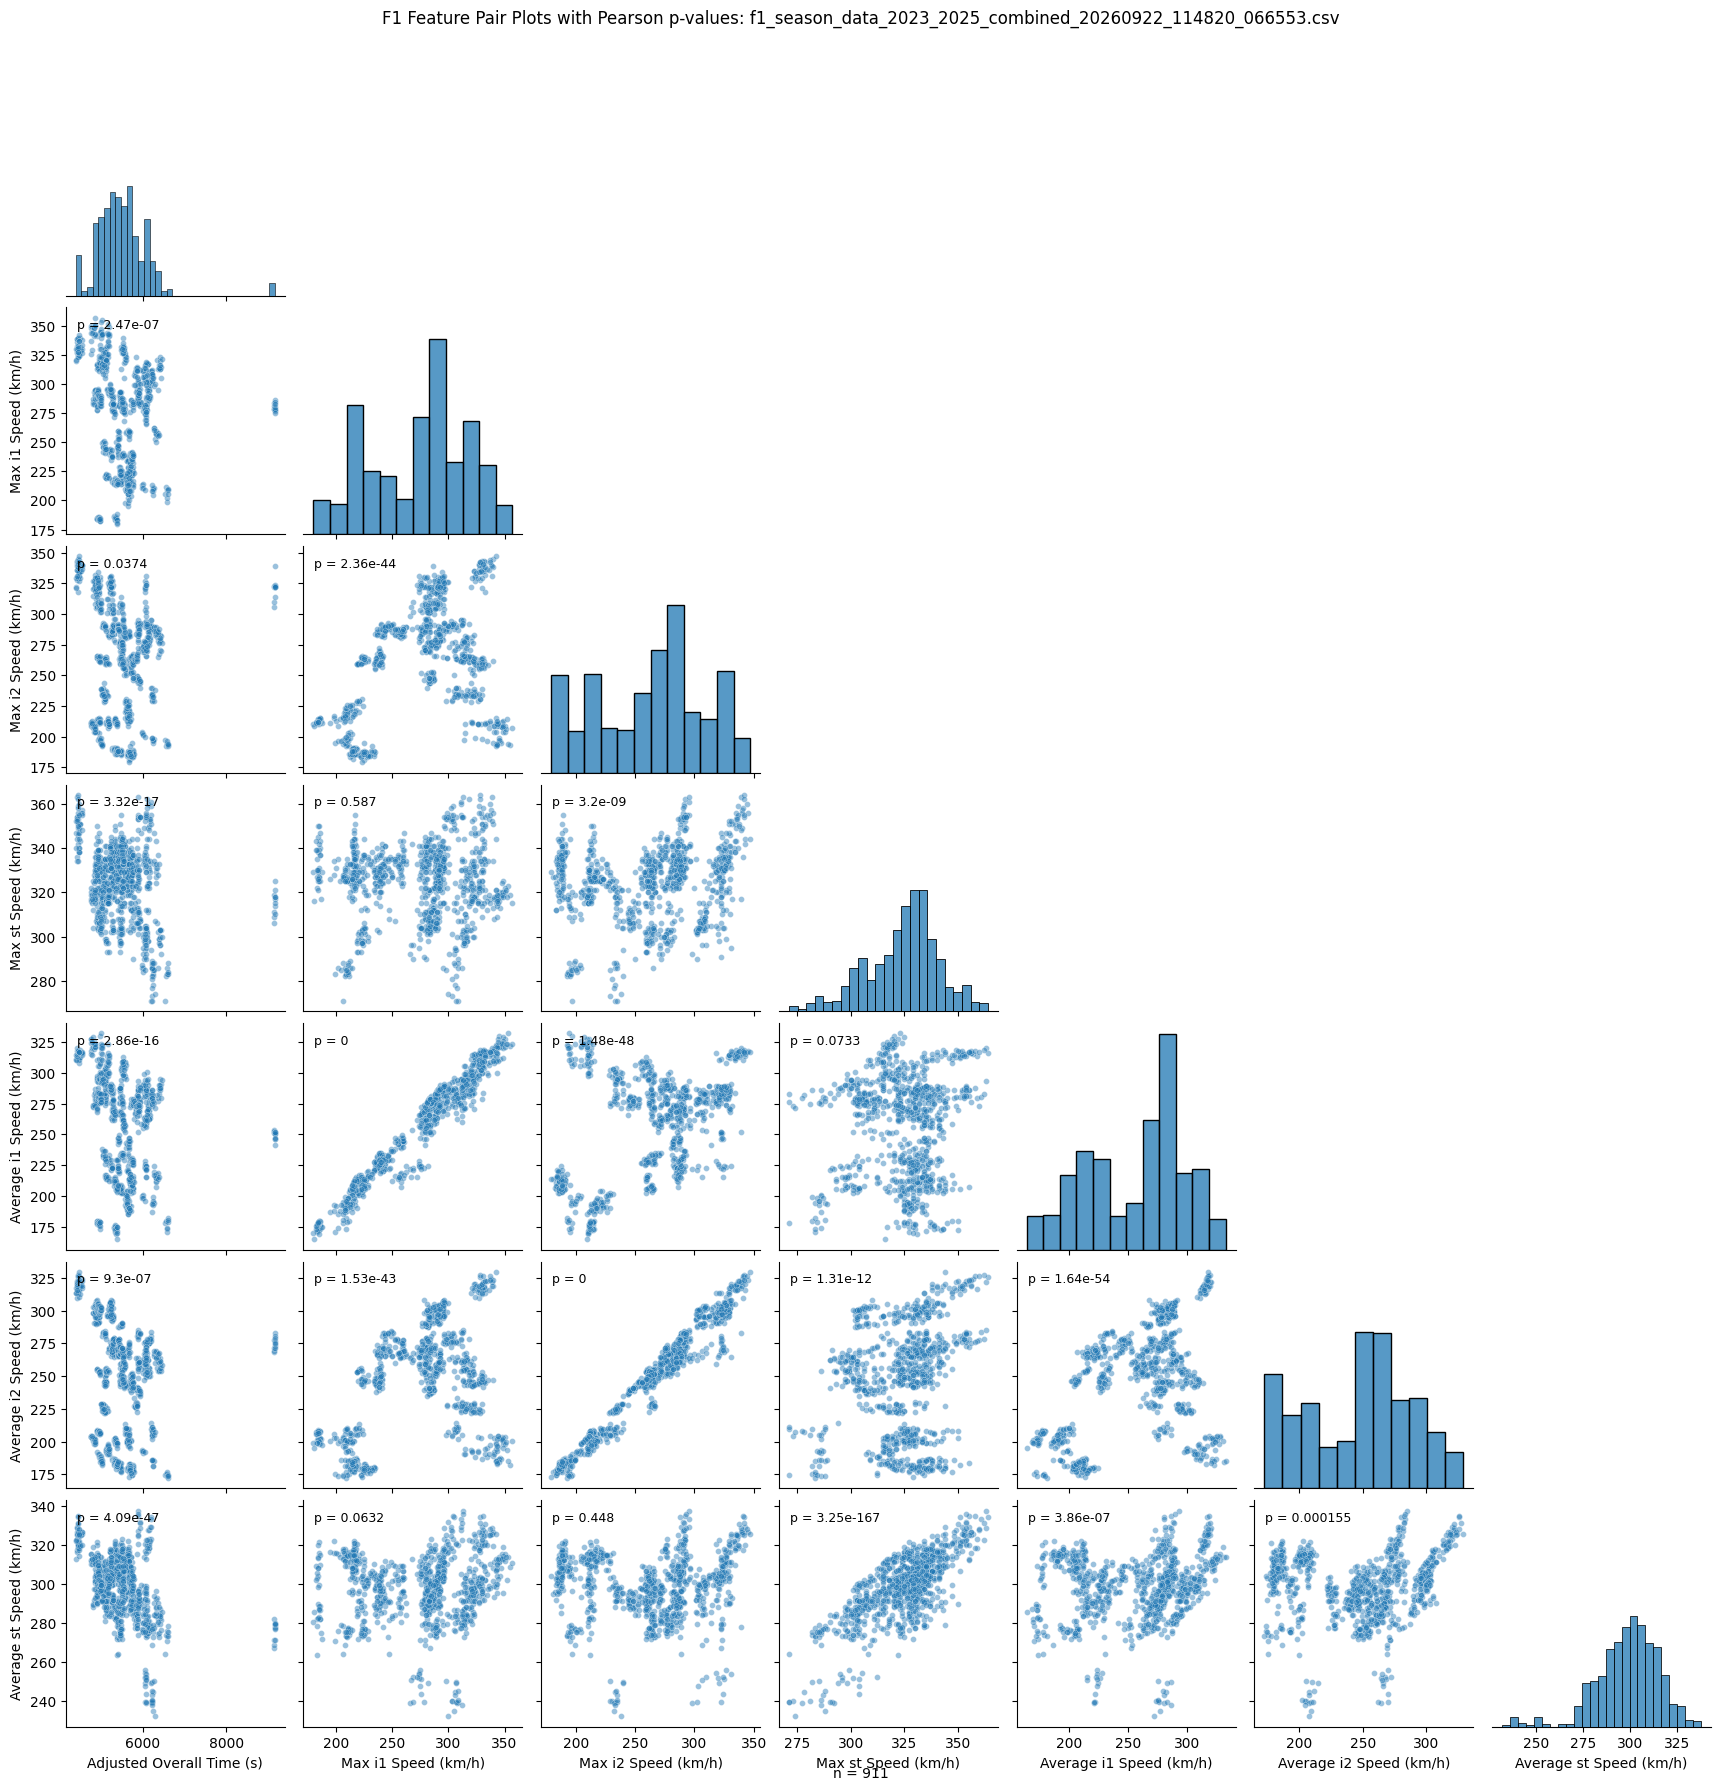

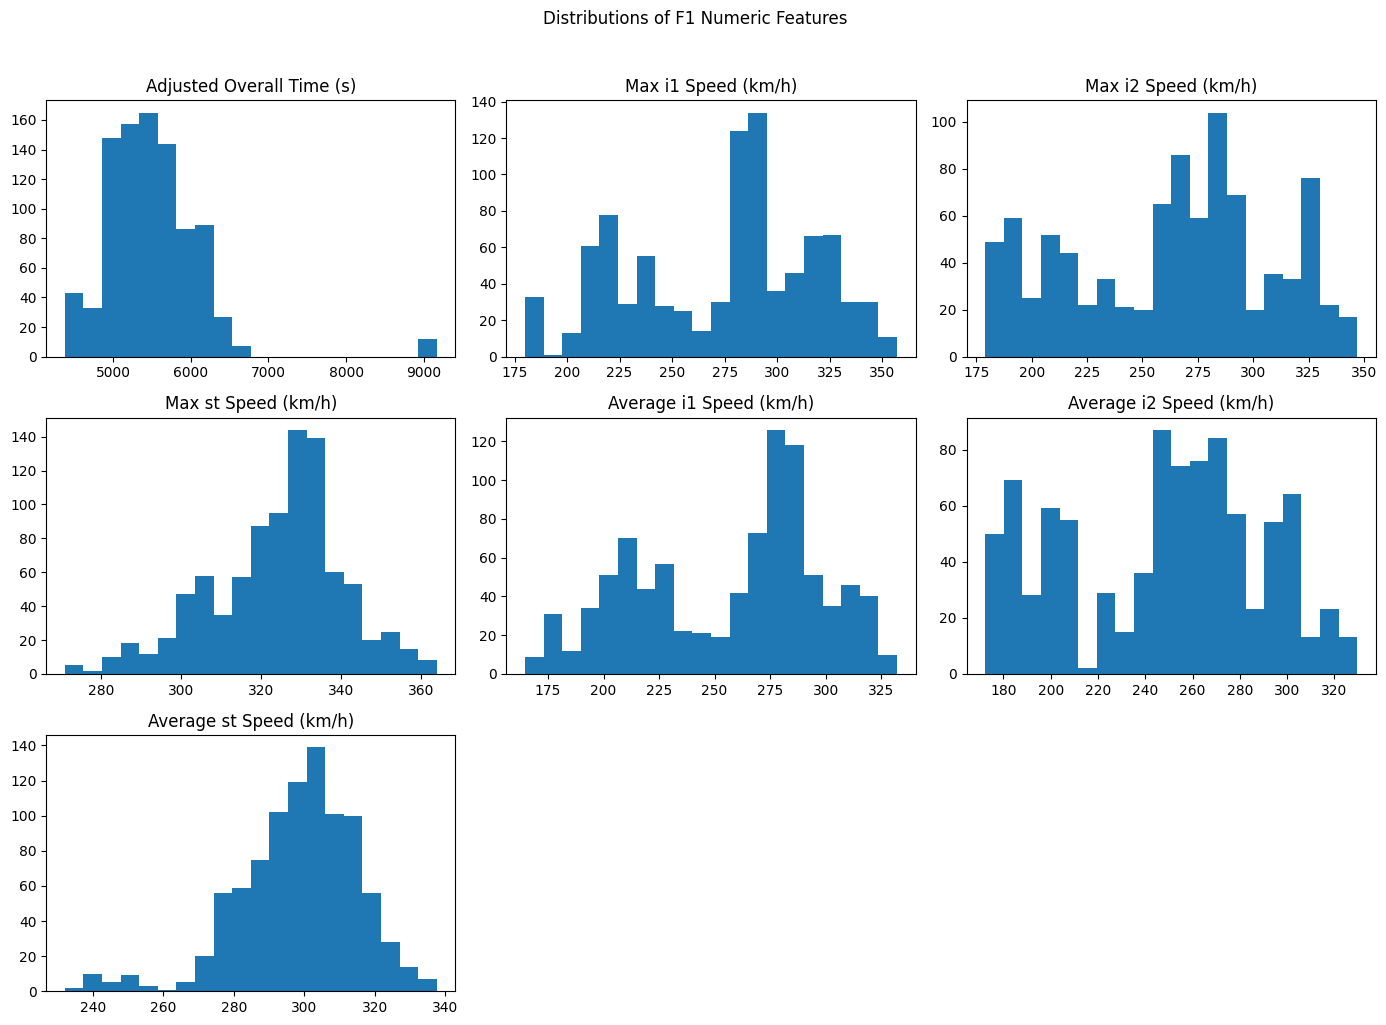

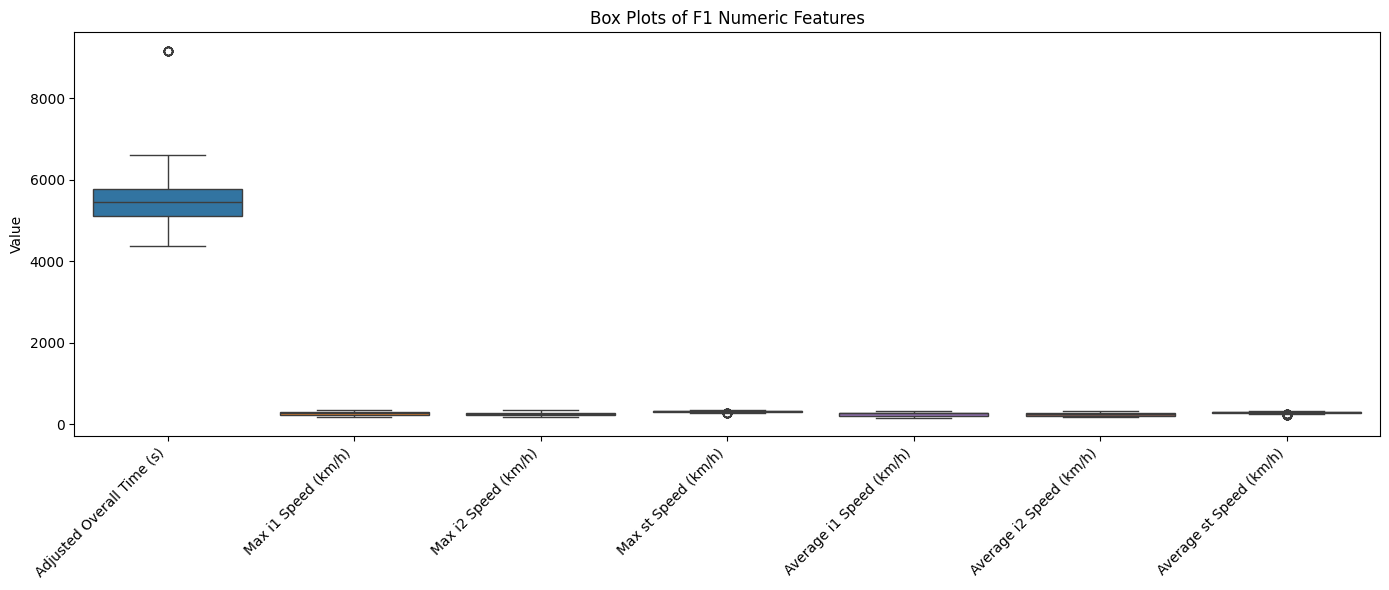

In [4]:
# Pair plots for the same F1 features used in the correlation heatmap
from scipy.stats import pearsonr

pair_plot = sns.pairplot(
    numeric_df,
    corner=True,
    diag_kind="hist",
    plot_kws={"alpha": 0.45, "s": 18},
 )
for row_index in range(1, len(numeric_df.columns)):
    for column_index in range(row_index):
        paired_values = numeric_df.iloc[:, [column_index, row_index]].dropna()
        if len(paired_values) >= 2:
            _, p_value = pearsonr(
                paired_values.iloc[:, 0],
                paired_values.iloc[:, 1],
            )
            pair_plot.axes[row_index, column_index].text(
                0.05,
                0.95,
                f"p = {p_value:.3g}",
                transform=pair_plot.axes[row_index, column_index].transAxes,
                ha="left",
                va="top",
                fontsize=9,
            )
pair_plot.figure.suptitle(
    f"F1 Feature Pair Plots with Pearson p-values: {latest_csv.name}",
    y=1.02,
 )
pair_plot.figure.text(0.5, 0.01, f"n = {len(numeric_df)}", ha="center")
plt.show()

# Visualize distributions for the same heatmap features
numeric_df.hist(bins=20, figsize=(14, 10), grid=False)
plt.suptitle("Distributions of F1 Numeric Features", y=1.02)
plt.tight_layout()
plt.show()

# Box plots for the same heatmap features, excluding adjusted race time
plt.figure(figsize=(14, 6))
sns.boxplot(data=numeric_df)
plt.title("Box Plots of F1 Numeric Features")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

## First Visualizations Interpretation
* Remove 2023 Melbourne Australia from rows in pair plots and correlation. The Race held the record for most red flags in one race and skewed the data with excessive stoppage time in the Adjust Overall Time Variable.
* Remove box plot for Adjusted Overall Time (s). Scale of the Adjusted Overall Time box plot makes the others unusable and the reference is not insightful.

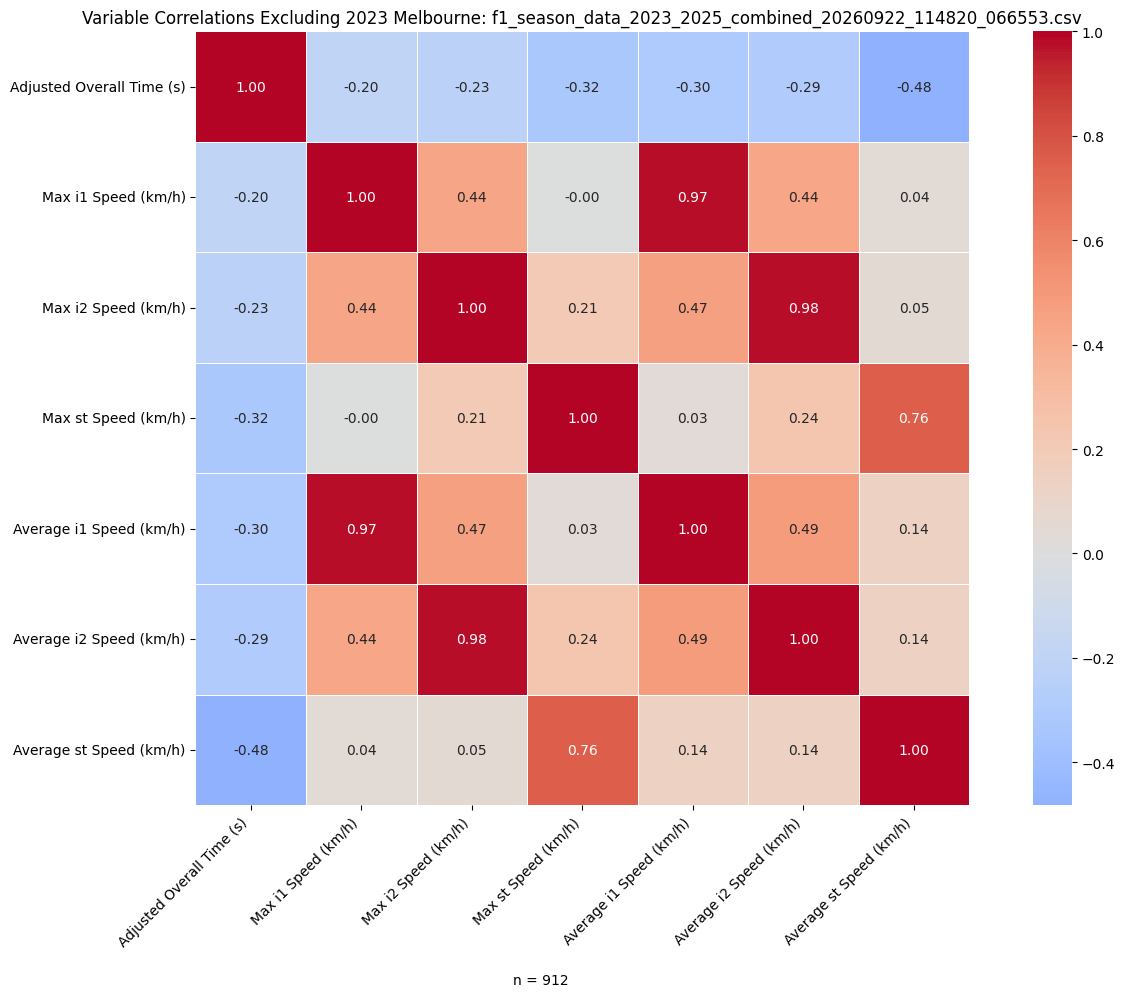

In [5]:
"""Create a second corrected correlation heatmap from the engineered race dataset."""

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

DATA_DIRECTORY = Path.cwd() / "data"
csv_files = sorted(
    DATA_DIRECTORY.glob("*.csv"),
    key=lambda file_path: file_path.stat().st_mtime,
)

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {DATA_DIRECTORY.resolve()}")

latest_csv = csv_files[-1]
df = pd.read_csv(latest_csv)

required_time_column = "Adjusted Overall Time (s)"
if required_time_column not in df.columns:
    raise ValueError(f"CSV is missing the required column: {required_time_column}")

df = df.dropna(subset=[required_time_column])
df = df.loc[
    ~(
        df["Year"].eq(2023)
        & df["Location"].eq("Melbourne")
        & df["Country"].eq("Australia")
    )
]

numeric_df = df.select_dtypes(include="number").drop(
    columns=[
        "Session Key",
        "Driver Number",
        "Position",
        "Overall Time (s)",
        "Lane Duration (s)",
        "Year",
    ],
    errors="ignore",
)

if numeric_df.shape[1] < 2:
    raise ValueError("At least two numeric variables are required for a correlation heatmap.")

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
)
plt.title(f"Variable Correlations Excluding 2023 Melbourne: {latest_csv.name}")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.gcf().text(0.5, 0.01, f"n = {len(numeric_df)}", ha="center")
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

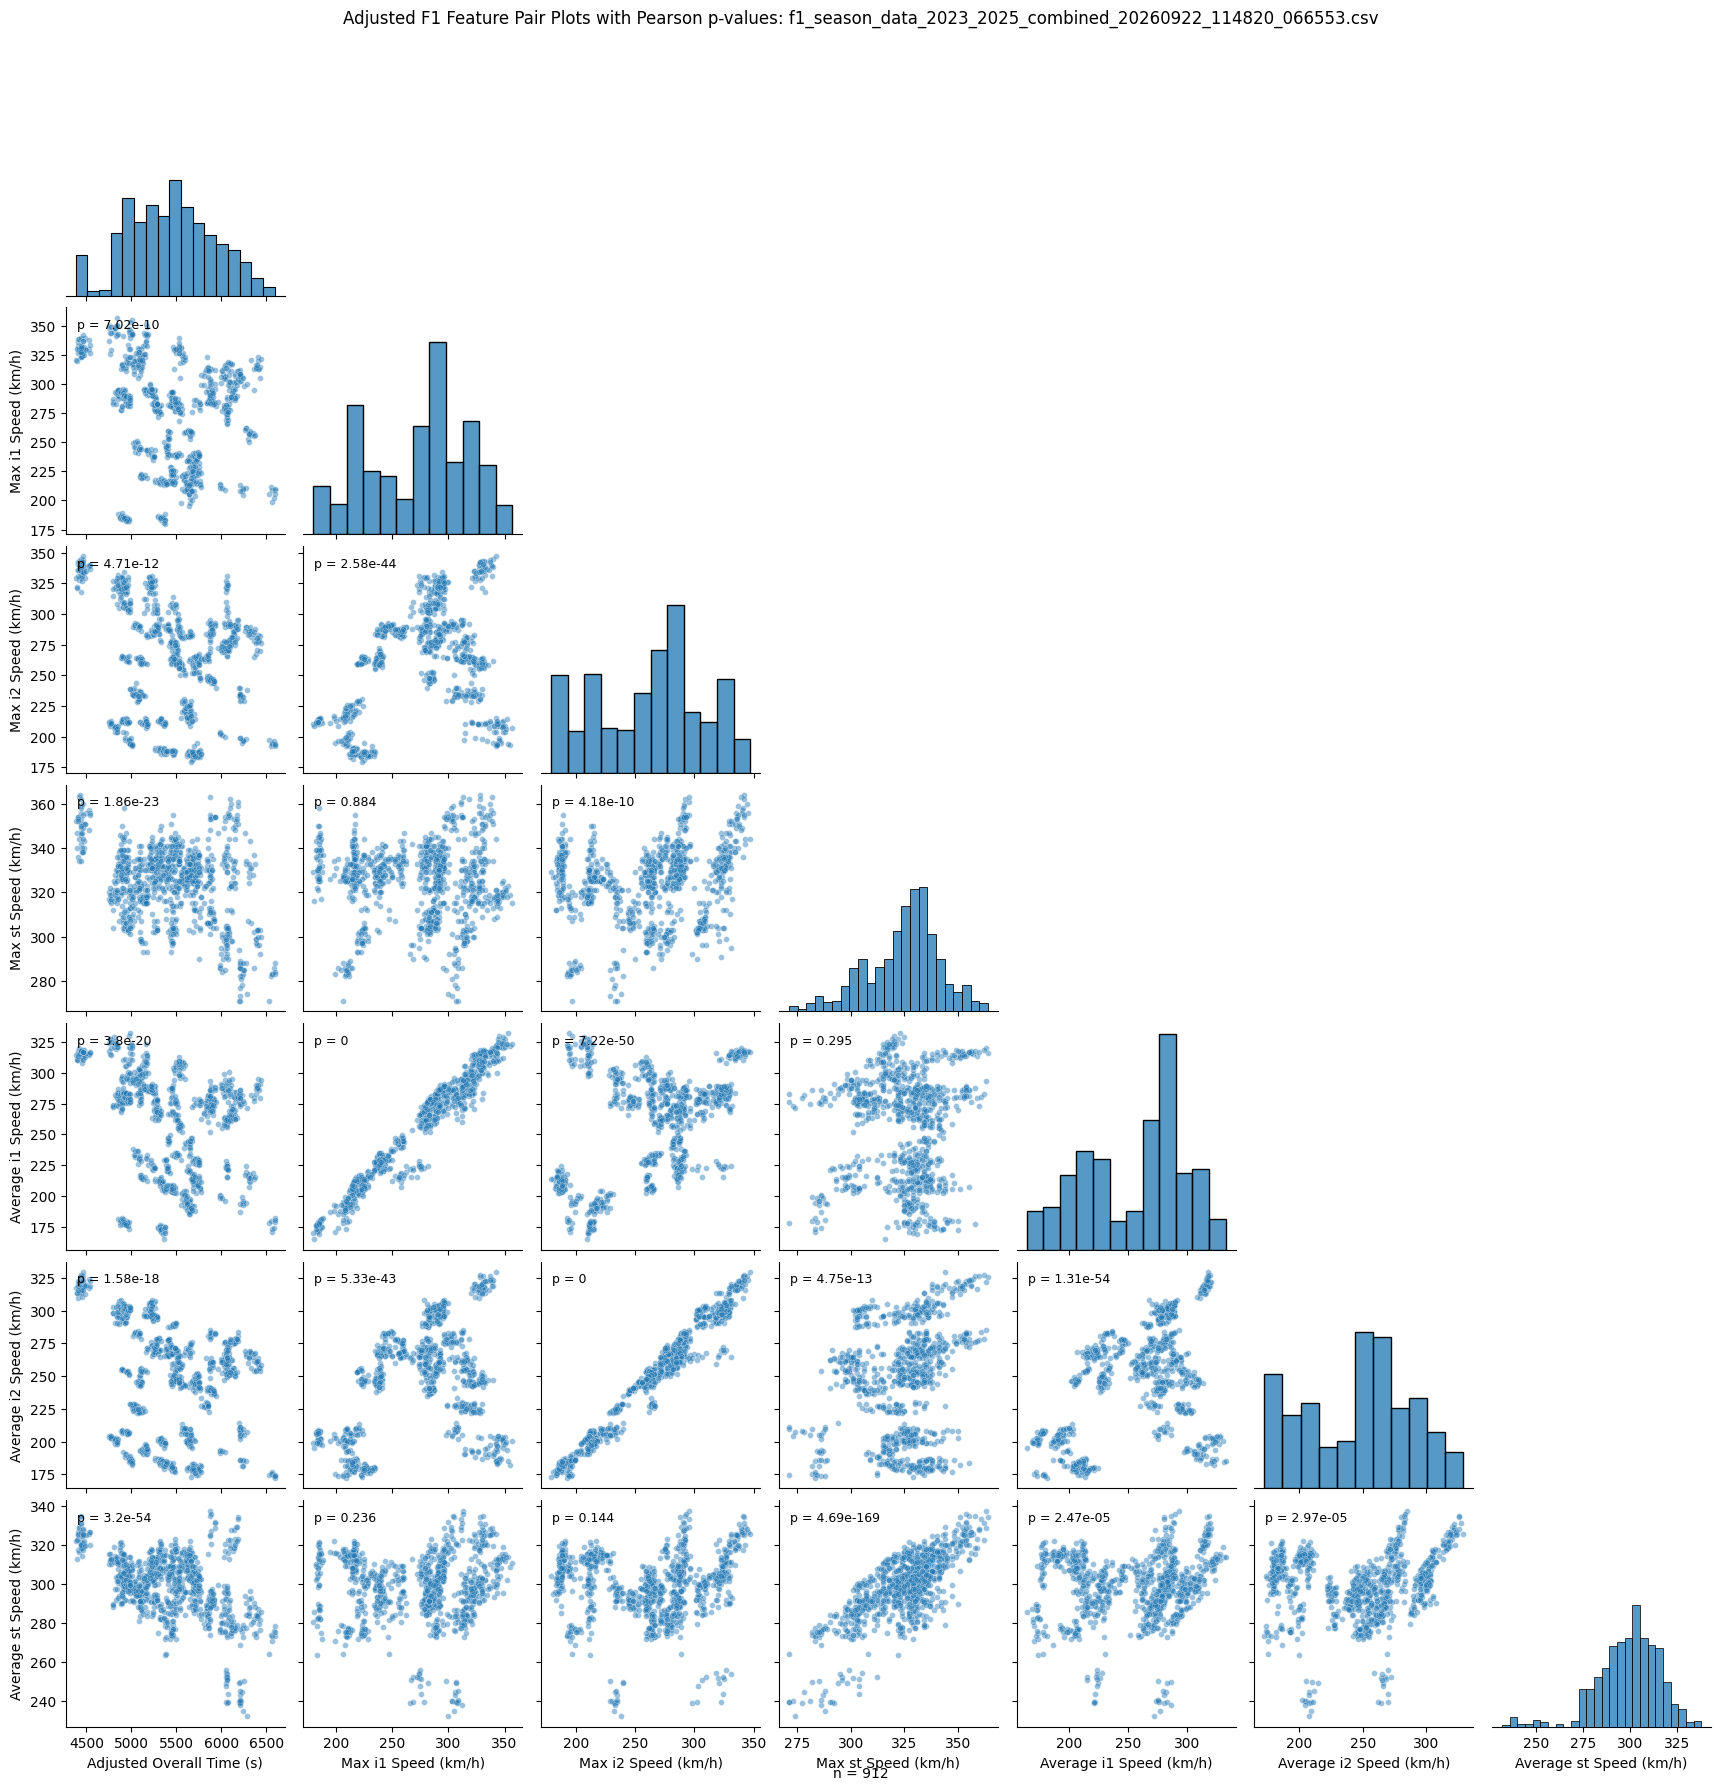

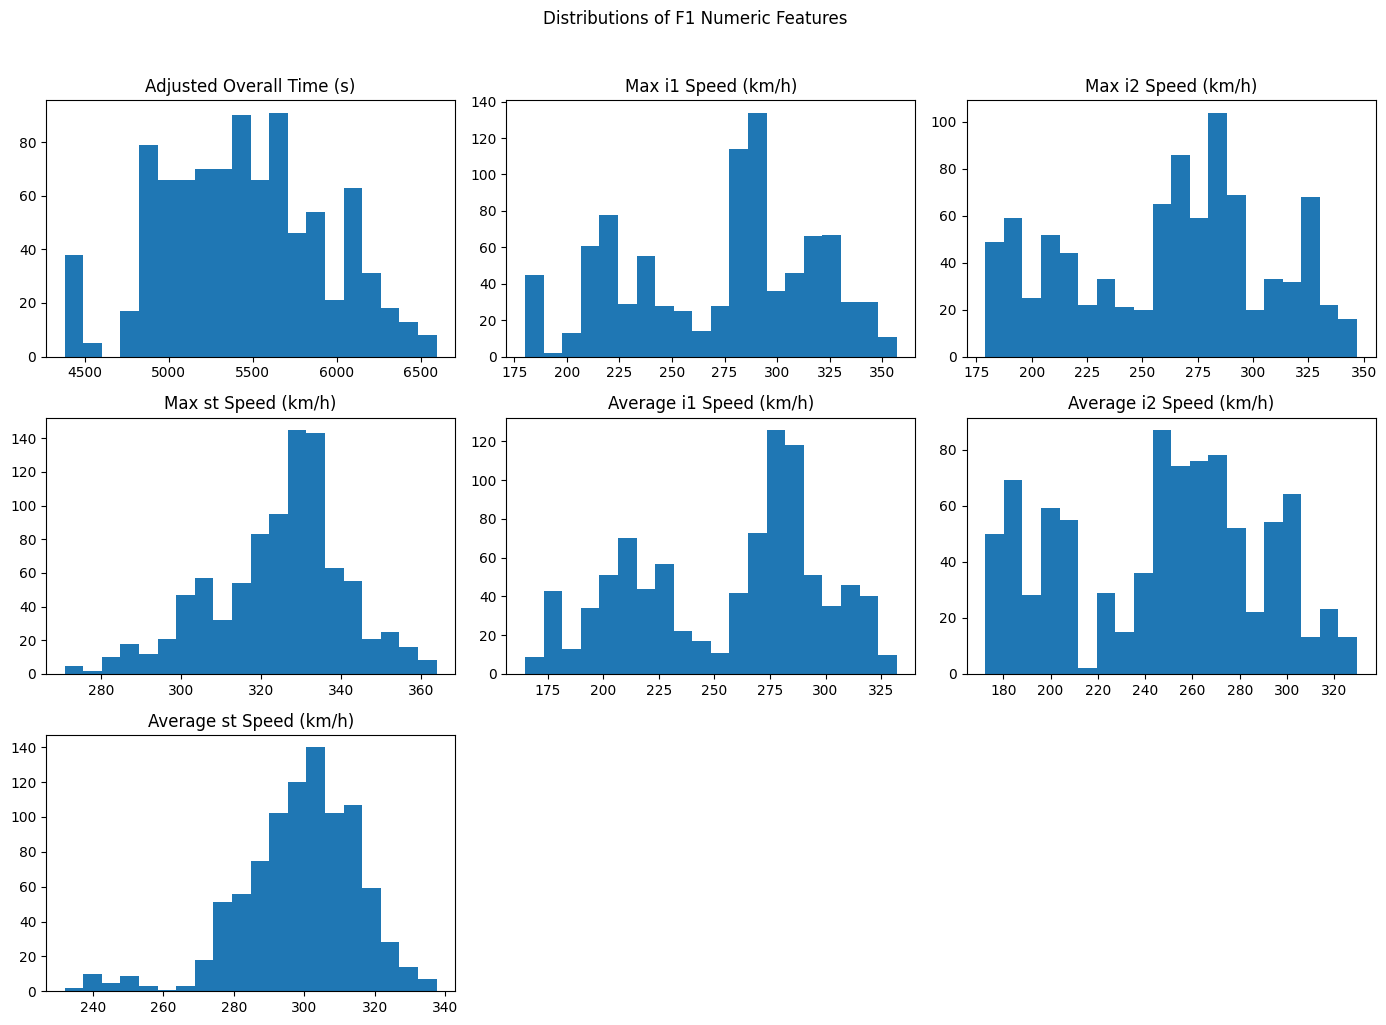

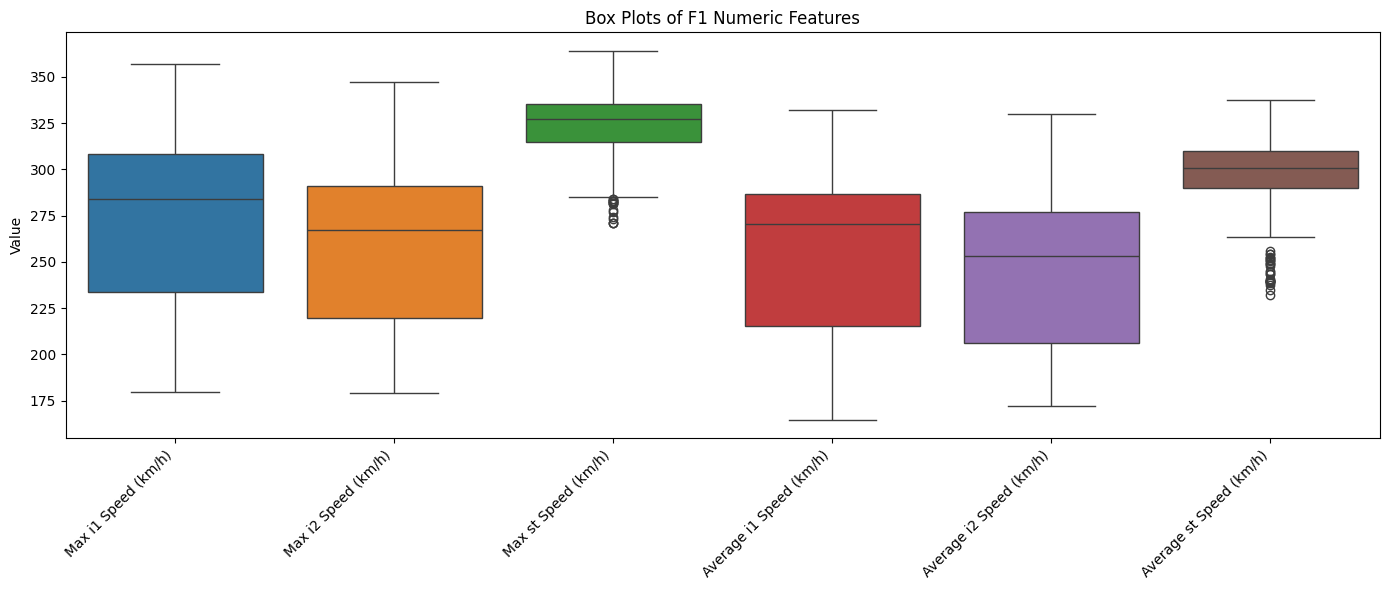

In [6]:
# Pair plots for the adjusted F1 features used in the second correlation heatmap
from scipy.stats import pearsonr

pair_plot = sns.pairplot(
    numeric_df,
    corner=True,
    diag_kind="hist",
    plot_kws={"alpha": 0.45, "s": 18},
 )
for row_index in range(1, len(numeric_df.columns)):
    for column_index in range(row_index):
        paired_values = numeric_df.iloc[:, [column_index, row_index]].dropna()
        if len(paired_values) >= 2:
            _, p_value = pearsonr(
                paired_values.iloc[:, 0],
                paired_values.iloc[:, 1],
            )
            pair_plot.axes[row_index, column_index].text(
                0.05,
                0.95,
                f"p = {p_value:.3g}",
                transform=pair_plot.axes[row_index, column_index].transAxes,
                ha="left",
                va="top",
                fontsize=9,
            )
pair_plot.figure.suptitle(
    f"Adjusted F1 Feature Pair Plots with Pearson p-values: {latest_csv.name}",
    y=1.02,
 )
pair_plot.figure.text(0.5, 0.01, f"n = {len(numeric_df)}", ha="center")
plt.show()

# Visualize distributions for the same heatmap features
numeric_df.hist(bins=20, figsize=(14, 10), grid=False)
plt.suptitle("Distributions of F1 Numeric Features", y=1.02)
plt.tight_layout()
plt.show()

# Box plots for the same heatmap features
boxplot_df = numeric_df.drop(columns=["Adjusted Overall Time (s)"], errors="ignore")
plt.figure(figsize=(14, 6))
sns.boxplot(data=boxplot_df)
plt.title("Box Plots of F1 Numeric Features")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

In [9]:
import numpy as np

# Descriptive Statistics
print("\nDescriptive Statistics")
print("----------------------")
numeric_columns = numeric_df.select_dtypes(include=[np.number]).columns
print("Central Tendency Measures:")
print(numeric_df[numeric_columns].describe().loc[['mean', '50%']])
print("\nDispersion Measures:")
print(numeric_df[numeric_columns].describe().loc[['std', 'min', 'max']])

# Check for distribution normality (skewness and kurtosis)
print("\nDistribution Measures:")
print("------------------------")
print("Skewness:")
print(numeric_df[numeric_columns].skew())
print("Kurtosis:")
print(numeric_df[numeric_columns].kurt())

print("\nData Quality")
print("------------")
print(f"Duplicated Rows: {numeric_df.duplicated().sum()}")
print("Checking for Inconsistent Values:")
print(numeric_df.apply(lambda x: x.value_counts().index[0]).to_frame('most_frequent_value'))


Descriptive Statistics
----------------------
Central Tendency Measures:
      Adjusted Overall Time (s)  Max i1 Speed (km/h)  Max i2 Speed (km/h)  \
mean                5442.783939           272.713816           262.032258   
50%                 5447.134000           284.000000           267.000000   

      Max st Speed (km/h)  Average i1 Speed (km/h)  Average i2 Speed (km/h)  \
mean           324.530702               255.915400               247.079691   
50%            327.000000               270.417376               253.196429   

      Average st Speed (km/h)  
mean               298.798917  
50%                300.760782  

Dispersion Measures:
     Adjusted Overall Time (s)  Max i1 Speed (km/h)  Max i2 Speed (km/h)  \
std                  477.20886            44.817159            44.974827   
min                 4379.78000           180.000000           179.000000   
max                 6595.37100           357.000000           347.000000   

     Max st Speed (km/h)  Average

## Second Interpretation
* Correlations are very sporadic
    *  Major track differences may be a factor in varied groupings of data points leading to lesser correlation values

* High Kurtosis (+1.88) in Average st Speed demonstrates a tight group of data points that may suggest the similarly built machines top out around the same speeds on most tracks. A similar analysis can be crawn from the Average and Max Speed Trap Speeds on the Box plots. The standard deviation is much less than the i1 and i2 speed datasets. This may also suggest the i1 and i2 speed sensors serve different purposes depending on the track.

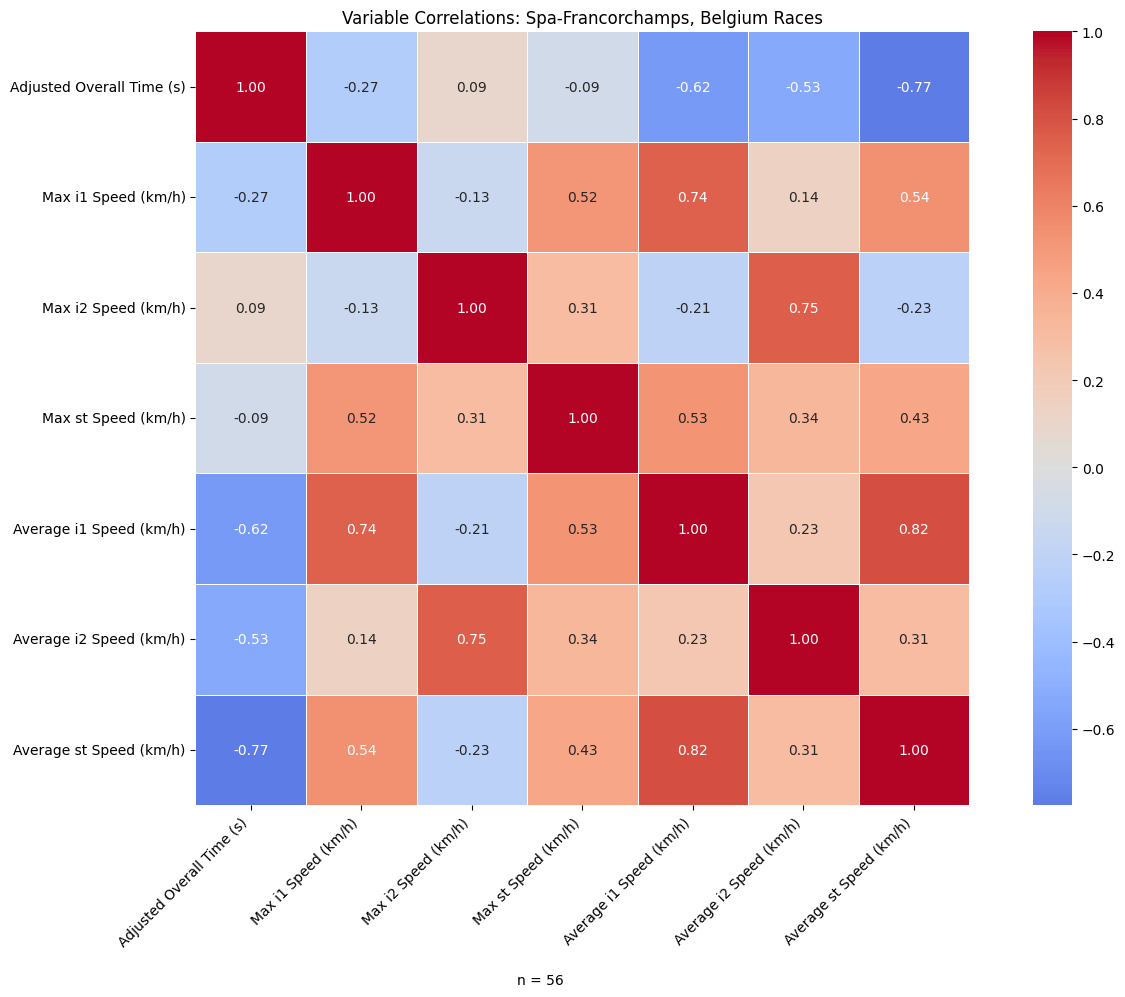

In [10]:
"""Create a correlation heatmap using only Spa-Francorchamps, Belgium races."""
spa_race_mask = (
    df["Location"].eq("Spa-Francorchamps")
    & df["Country"].eq("Belgium")
)
spa_df = numeric_df.loc[numeric_df.index.intersection(df.index[spa_race_mask])].copy()

if spa_df.shape[1] < 2:
    raise ValueError("At least two numeric variables are required for a correlation heatmap.")
if spa_df.empty:
    raise ValueError("No Spa-Francorchamps, Belgium race rows were found in the dataset.")

correlation_matrix = spa_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
)
plt.title("Variable Correlations: Spa-Francorchamps, Belgium Races")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.gcf().text(0.5, 0.01, f"n = {len(spa_df)}", ha="center")
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

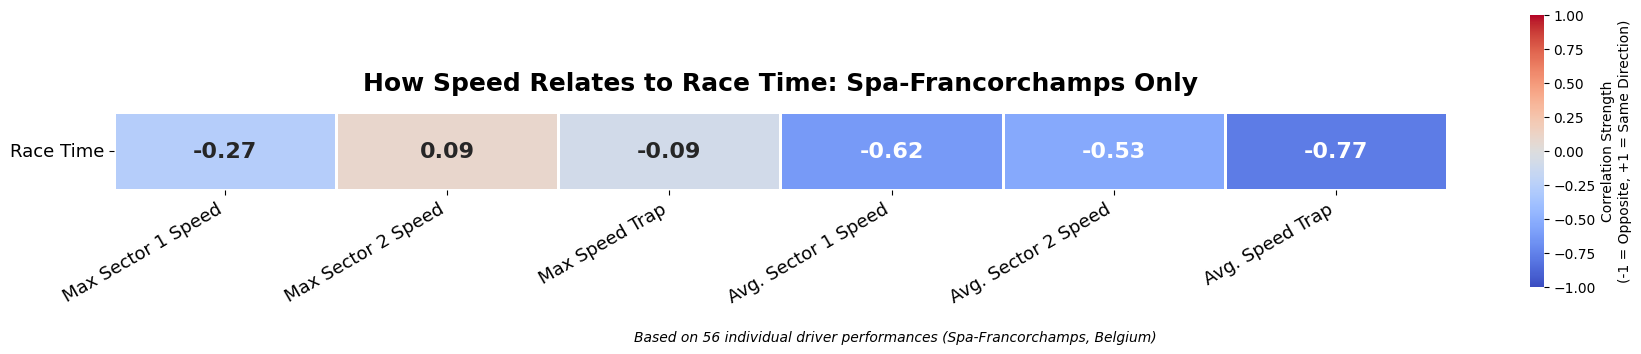

In [45]:
"""Compares only the Adjusted Overall Time against the selected F1 speed features in a correlation heatmap."""

target_feature = "Adjusted Overall Time (s)"
speed_features = [
    feature for feature in spa_df.columns if feature != target_feature
]

spa_correlation_matrix = spa_df.corr()
target_corr_row = spa_correlation_matrix.loc[[target_feature], speed_features]

# Plain-language labels so the chart reads well for non-technical audiences
friendly_labels = {
    "Max i1 Speed (km/h)": "Max Sector 1 Speed",
    "Max i2 Speed (km/h)": "Max Sector 2 Speed",
    "Max st Speed (km/h)": "Max Speed Trap",
    "Average i1 Speed (km/h)": "Avg. Sector 1 Speed",
    "Average i2 Speed (km/h)": "Avg. Sector 2 Speed",
    "Average st Speed (km/h)": "Avg. Speed Trap",
}
display_row = target_corr_row.rename(columns=friendly_labels)
display_row.index = ["Race Time"]

plt.figure(figsize=(18, 3.5))
heatmap_axes = sns.heatmap(
    display_row,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=False,
    linewidths=2,
    linecolor="white",
    annot_kws={"size": 16, "weight": "bold"},
    cbar_kws={"label": "Correlation Strength\n(-1 = Opposite, +1 = Same Direction)"},
)
heatmap_axes.set_aspect(0.35)
plt.title(
    "How Speed Relates to Race Time: Spa-Francorchamps Only",
    fontsize=18,
    fontweight="bold",
    pad=16,
)
plt.gcf().text(
    0.5, 0.01,
    f"Based on {len(spa_df)} individual driver performances (Spa-Francorchamps, Belgium)",
    ha="center",
    fontsize=10,
    style="italic",
)
plt.xticks(rotation=30, ha="right", fontsize=13)
plt.yticks(rotation=0, fontsize=13)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()


## Spa-Francorchamps Only Insights

* I decided to use Spa-Francorchamps as a targeted analysis sample because the 2025 and 2026 races created outlier results due to track conditions worth including in further analysis.
* The correlations appear stronger for average speeds but have less data to back
* Near zero or low correlations for max speeds
* At 2026 Spa Race, Charles Leclerc beat Kimi Antonelli in every average speed metric, but still lost by 2 seconds.
* 2025 and 2026 races had extended overall times for wet conditions. Though causation from this cannot be proved, the max i2 speeds and max Speed Trap speeds suffered in their correlation with adjusted overall time. This could potentially correlate excessive speeds and decreased driver handling (causing drivers to extend the distance driven at higher recorded velocities)


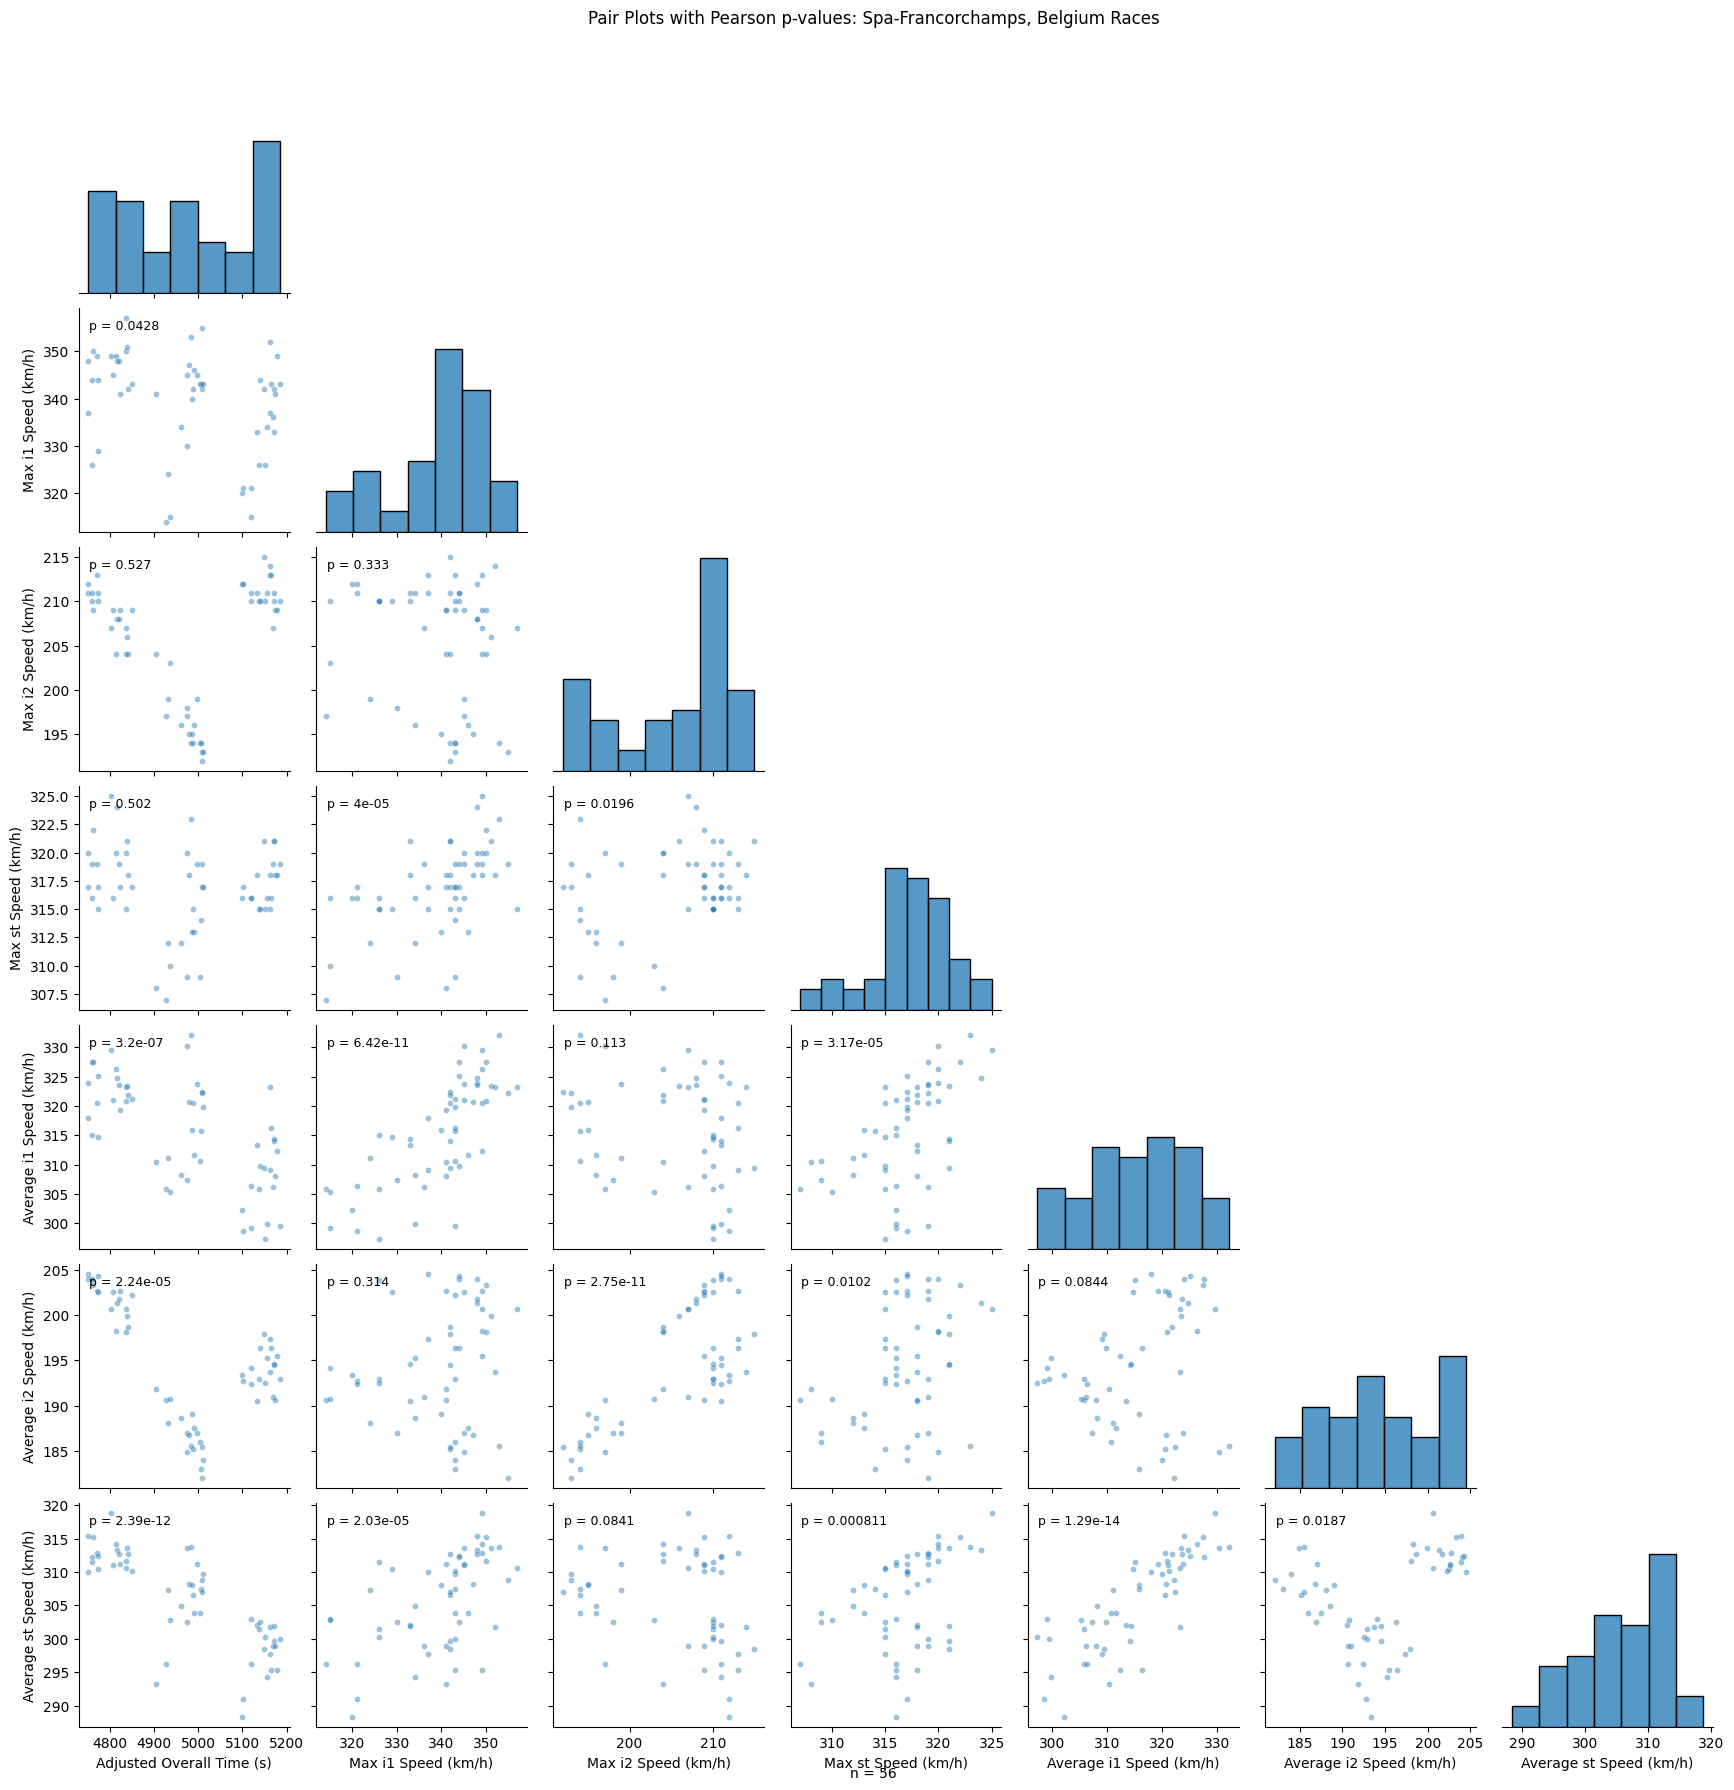

In [12]:
"""Create pair plots with p-values using Spa-Francorchamps, Belgium races."""
from scipy.stats import pearsonr

spa_race_mask = (
    df["Location"].eq("Spa-Francorchamps")
    & df["Country"].eq("Belgium")
)
spa_df = numeric_df.loc[numeric_df.index.intersection(df.index[spa_race_mask])].copy()

if spa_df.shape[1] < 2:
    raise ValueError("At least two numeric variables are required for pair plots.")
if spa_df.empty:
    raise ValueError("No Spa-Francorchamps, Belgium race rows were found in the dataset.")

pair_plot = sns.pairplot(
    spa_df,
    corner=True,
    diag_kind="hist",
    plot_kws={"alpha": 0.45, "s": 18},
 )
for row_index in range(1, len(spa_df.columns)):
    for column_index in range(row_index):
        paired_values = spa_df.iloc[:, [column_index, row_index]].dropna()
        if len(paired_values) >= 2:
            _, p_value = pearsonr(
                paired_values.iloc[:, 0],
                paired_values.iloc[:, 1],
            )
            pair_plot.axes[row_index, column_index].text(
                0.05,
                0.95,
                f"p = {p_value:.3g}",
                transform=pair_plot.axes[row_index, column_index].transAxes,
                ha="left",
                va="top",
                fontsize=9,
            )

pair_plot.figure.suptitle(
    "Pair Plots with Pearson p-values: Spa-Francorchamps, Belgium Races",
    y=1.02,
 )
pair_plot.figure.text(0.5, 0.01, f"n = {len(spa_df)}", ha="center")
plt.show()

## Spa-Francorchamps Data Interpretation
* Consistently higher p-values across the pair plots but still relatively low on key metrics (Average Speed Trap Speed v Adjusted Overall Time)
* Lesser number of data points creates other than normal distributions across histogram plots

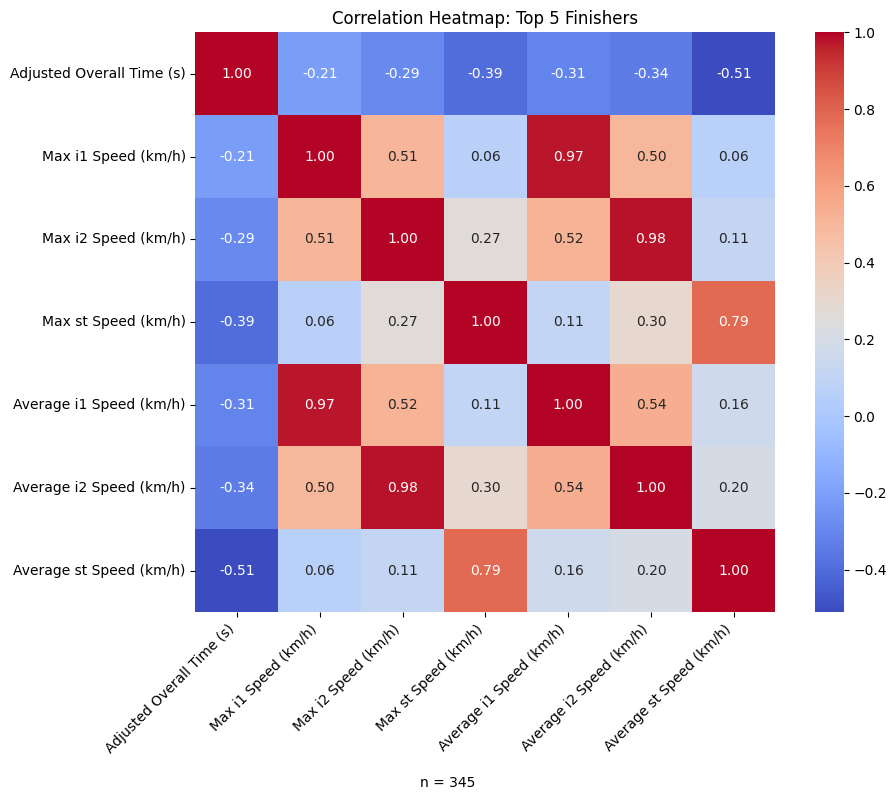

In [13]:
"""Create a correlation heatmap for Top 5 finishers in each race."""

top_5_mask = df["Position"].le(5)
top_5_df = numeric_df.loc[numeric_df.index.intersection(df.index[top_5_mask])].copy()

if top_5_df.shape[1] < 2:
    raise ValueError("At least two numeric variables are required for correlation heatmaps.")
if top_5_df.empty:
    raise ValueError("No Top 5 finisher rows were found in the dataset.")

correlation_matrix = top_5_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar=True,
    square=True,
)
plt.title("Correlation Heatmap: Top 5 Finishers")
plt.gcf().text(0.5, 0.01, f"n = {len(top_5_df)}", ha="center")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

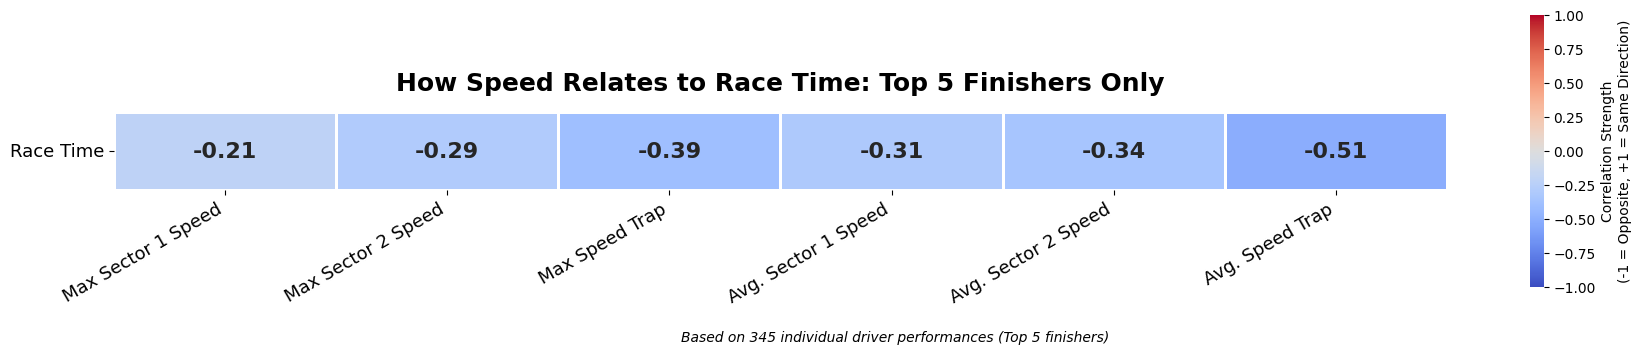

In [47]:
""" Creates a correlation heatmap for the target feature Adjusted Overall Time (s) and its relationship with other features."""

target_feature = "Adjusted Overall Time (s)"
speed_features = [
    feature for feature in top_5_df.columns if feature != target_feature
]

top_5_correlation_matrix = top_5_df.corr()
target_corr_row = top_5_correlation_matrix.loc[[target_feature], speed_features]

# Plain-language labels so the chart reads well for non-technical audiences
friendly_labels = {
    "Max i1 Speed (km/h)": "Max Sector 1 Speed",
    "Max i2 Speed (km/h)": "Max Sector 2 Speed",
    "Max st Speed (km/h)": "Max Speed Trap",
    "Average i1 Speed (km/h)": "Avg. Sector 1 Speed",
    "Average i2 Speed (km/h)": "Avg. Sector 2 Speed",
    "Average st Speed (km/h)": "Avg. Speed Trap",
}
display_row = target_corr_row.rename(columns=friendly_labels)
display_row.index = ["Race Time"]

plt.figure(figsize=(18, 3.5))
heatmap_axes = sns.heatmap(
    display_row,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=False,
    linewidths=2,
    linecolor="white",
    annot_kws={"size": 16, "weight": "bold"},
    cbar_kws={"label": "Correlation Strength\n(-1 = Opposite, +1 = Same Direction)"},
)
heatmap_axes.set_aspect(0.35)
plt.title(
    "How Speed Relates to Race Time: Top 5 Finishers Only",
    fontsize=18,
    fontweight="bold",
    pad=16,
)
plt.gcf().text(
    0.5, 0.01,
    f"Based on {len(top_5_df)} individual driver performances (Top 5 finishers)",
    ha="center",
    fontsize=10,
    style="italic",
)
plt.xticks(rotation=30, ha="right", fontsize=13)
plt.yticks(rotation=0, fontsize=13)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

## Top 5 Finisher Interpretation
* Correlations are stronger across the dataset, but not as strong as assumed or expected


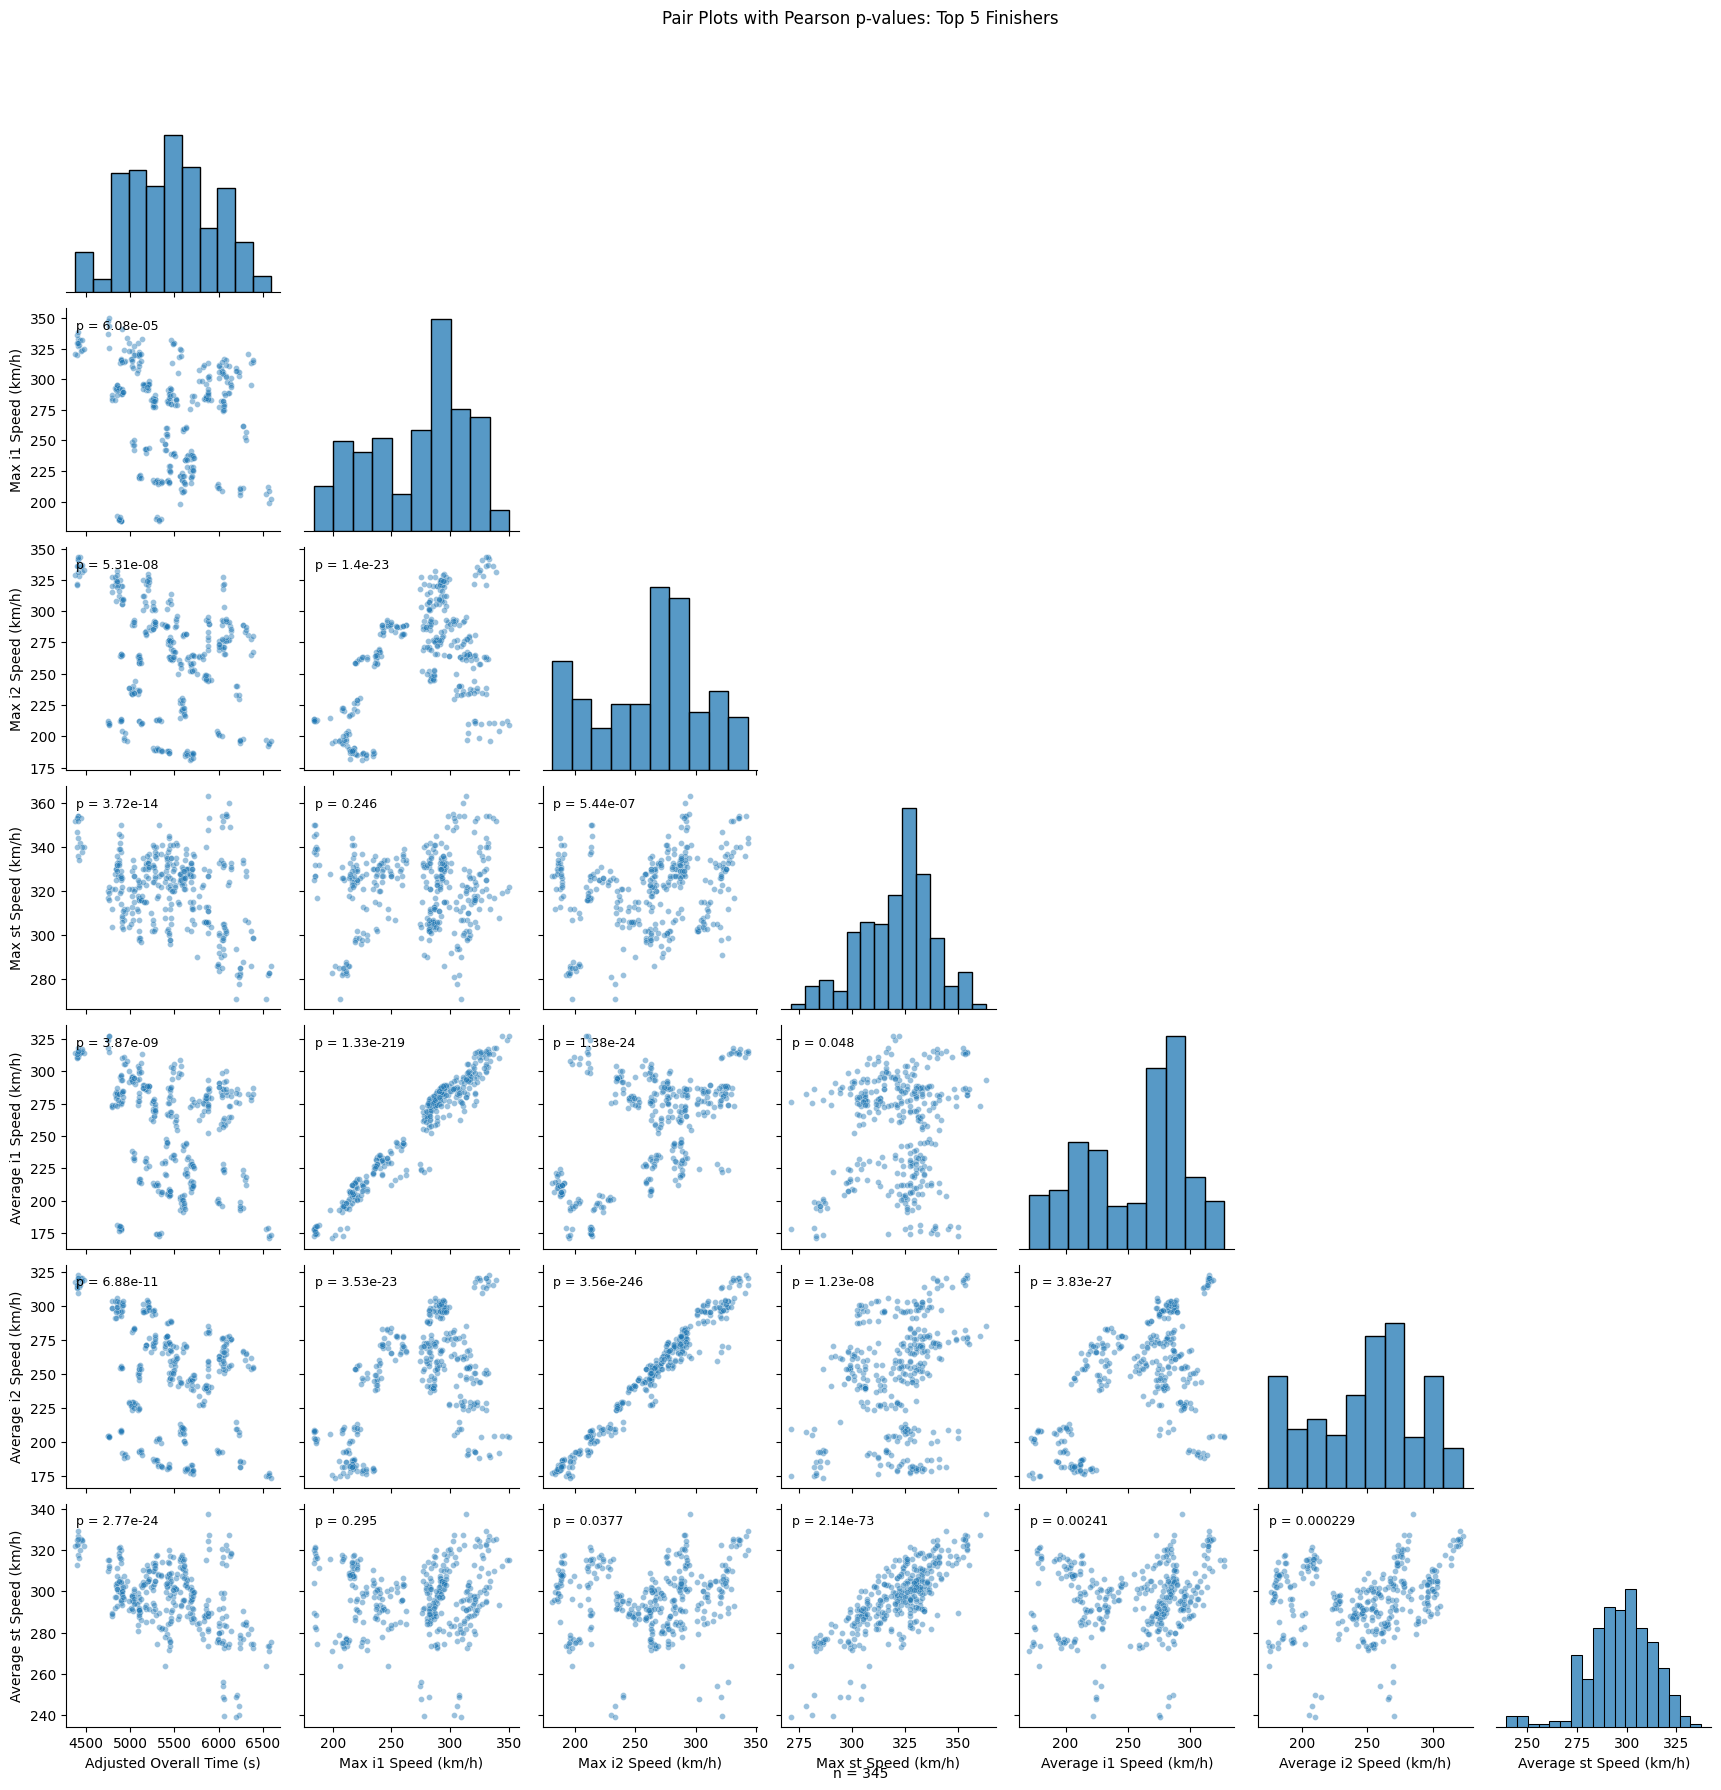

In [14]:
"""Create pair plots with p-values for Top 5 finishers in each race."""
from scipy.stats import pearsonr

top_5_mask = df["Position"].le(5)
top_5_df = numeric_df.loc[numeric_df.index.intersection(df.index[top_5_mask])].copy()

if top_5_df.shape[1] < 2:
    raise ValueError("At least two numeric variables are required for pair plots.")
if top_5_df.empty:
    raise ValueError("No Top 5 finisher rows were found in the dataset.")

pair_plot = sns.pairplot(
    top_5_df,
    corner=True,
    diag_kind="hist",
    plot_kws={"alpha": 0.45, "s": 18},
 )
for row_index in range(1, len(top_5_df.columns)):
    for column_index in range(row_index):
        paired_values = top_5_df.iloc[:, [column_index, row_index]].dropna()
        if len(paired_values) >= 2:
            _, p_value = pearsonr(
                paired_values.iloc[:, 0],
                paired_values.iloc[:, 1],
            )
            pair_plot.axes[row_index, column_index].text(
                0.05,
                0.95,
                f"p = {p_value:.3g}",
                transform=pair_plot.axes[row_index, column_index].transAxes,
                ha="left",
                va="top",
                fontsize=9,
            )

pair_plot.figure.suptitle(
    "Pair Plots with Pearson p-values: Top 5 Finishers",
    y=1.02,
 )
pair_plot.figure.text(0.5, 0.01, f"n = {len(top_5_df)}", ha="center")
plt.show()

## Feature Selection
* Three Features are the most interesting:
    * Average Intermediate 1 Speed: Ability to maintain high speeds in first sector
    * Average Speed Trap: Ability to regularly top out speed at most advantageous point on the track
    * Max i2 Speed: Regularly lower and initially negative correlation across dataset, but slightly positive correlation at Spa-Francorchamps dataset. Potentially evaluates drivers ability to handle difficult corners
    * The Skewness of each feature 

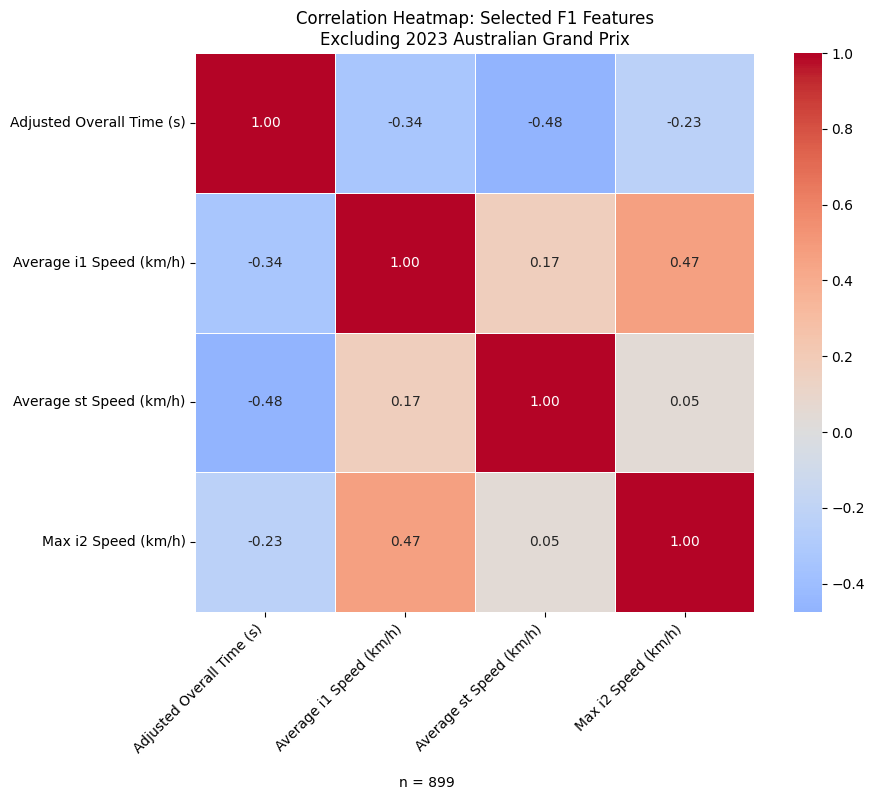

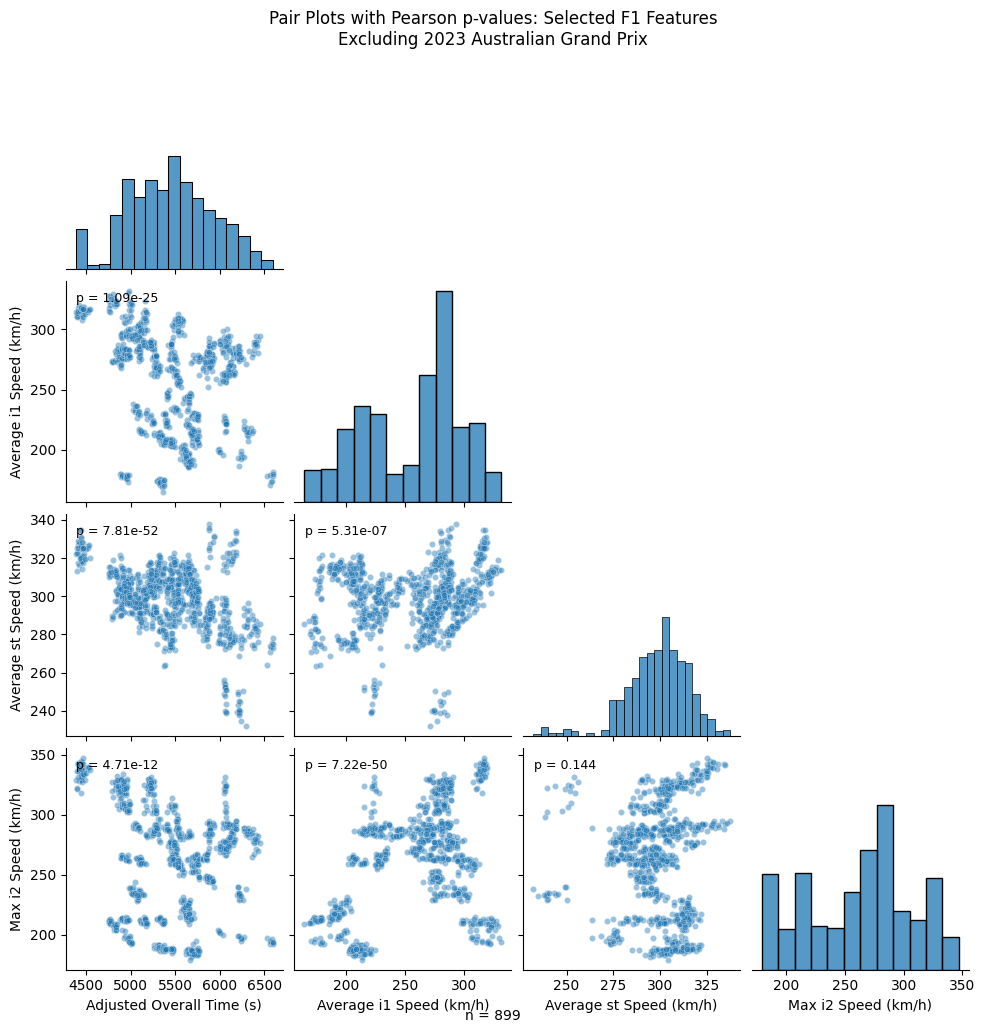

In [15]:
"""Create selected-feature heatmap and pair plots excluding the 2023 Australian Grand Prix."""
from scipy.stats import pearsonr

selected_features = [
    "Adjusted Overall Time (s)",
    "Average i1 Speed (km/h)",
    "Average st Speed (km/h)",
    "Max i2 Speed (km/h)",
]
missing_features = [
    feature for feature in selected_features if feature not in numeric_df.columns
]
if missing_features:
    raise ValueError(f"Missing selected features: {missing_features}")

analysis_mask = ~(
    df["Year"].eq(2023)
    & df["Location"].eq("Melbourne")
    & df["Country"].eq("Australia")
)
selected_df = numeric_df.loc[
    numeric_df.index.intersection(df.index[analysis_mask]),
    selected_features,
].dropna().copy()

if selected_df.empty:
    raise ValueError("No rows remain after excluding the 2023 Australian Grand Prix.")

# Correlation heatmap for the selected F1 features
correlation_matrix = selected_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar=True,
)
plt.title("Correlation Heatmap: Selected F1 Features\nExcluding 2023 Australian Grand Prix")
plt.gcf().text(0.5, 0.01, f"n = {len(selected_df)}", ha="center")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

# Pair plots with Pearson p-values for the selected F1 features
pair_plot = sns.pairplot(
    selected_df,
    corner=True,
    diag_kind="hist",
    plot_kws={"alpha": 0.45, "s": 20},
)
for row_index in range(1, len(selected_df.columns)):
    for column_index in range(row_index):
        paired_values = selected_df.iloc[:, [column_index, row_index]].dropna()
        if len(paired_values) >= 2:
            _, p_value = pearsonr(
                paired_values.iloc[:, 0],
                paired_values.iloc[:, 1],
            )
            pair_plot.axes[row_index, column_index].text(
                0.05,
                0.95,
                f"p = {p_value:.3g}",
                transform=pair_plot.axes[row_index, column_index].transAxes,
                ha="left",
                va="top",
                fontsize=9,
            )

pair_plot.figure.suptitle(
    "Pair Plots with Pearson p-values: Selected F1 Features\nExcluding 2023 Australian Grand Prix",
    y=1.02,
)
pair_plot.figure.text(0.5, 0.01, f"n = {len(selected_df)}", ha="center")
plt.show()

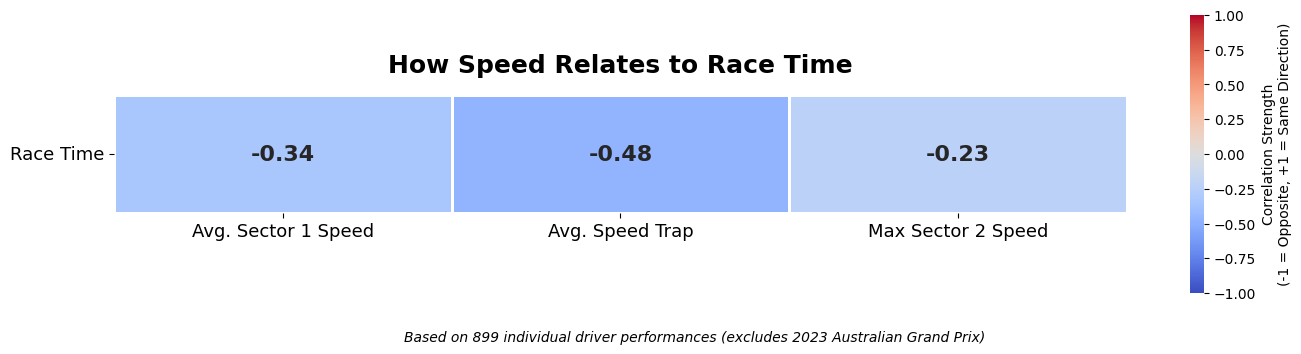

In [38]:
""" Produces heatmap depicting only the relationship between Adjusted overall time and other features."""

target_feature = "Adjusted Overall Time (s)"
other_features = [feature for feature in selected_df.columns if feature != target_feature]

# Single row of correlations: target feature vs each other feature
target_corr_row = correlation_matrix.loc[[target_feature], other_features]

# Plain-language labels so the chart reads well for non-technical audiences
friendly_labels = {
    "Average i1 Speed (km/h)": "Avg. Sector 1 Speed",
    "Average st Speed (km/h)": "Avg. Speed Trap",
    "Max i2 Speed (km/h)": "Max Sector 2 Speed",
}
display_row = target_corr_row.rename(columns=friendly_labels)
display_row.index = ["Race Time"]

plt.figure(figsize=(14, 3.5))
heatmap_axes = sns.heatmap(
    display_row,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=False,
    linewidths=2,
    linecolor="white",
    annot_kws={"size": 16, "weight": "bold"},
    cbar_kws={"label": "Correlation Strength\n(-1 = Opposite, +1 = Same Direction)"},
)
heatmap_axes.set_aspect(0.35)
plt.title(
    "How Speed Relates to Race Time",
    fontsize=18,
    fontweight="bold",
    pad=16,
)
plt.gcf().text(
    0.5, 0.01,
    f"Based on {len(selected_df)} individual driver performances (excludes 2023 Australian Grand Prix)",
    ha="center",
    fontsize=10,
    style="italic",
)
plt.xticks(rotation=0, ha="center", fontsize=13)
plt.yticks(rotation=0, fontsize=13)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()


## Final Interpretation
* Final plots provide inferred insights about purposes of sensors
    * Speed Trap reads the top speed of cars on the course
    * Intermediate 1 reads performance through the first section of the course
    * Intermedate 2 reads performance through second section, which may be more technical on average.

# Final Visualizations

C:\Users\Caleb\AppData\Local\Temp\ipykernel_38112\1406411382.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_xticklabels(["Avg i1", "Avg st", "Max i2"], rotation=0)


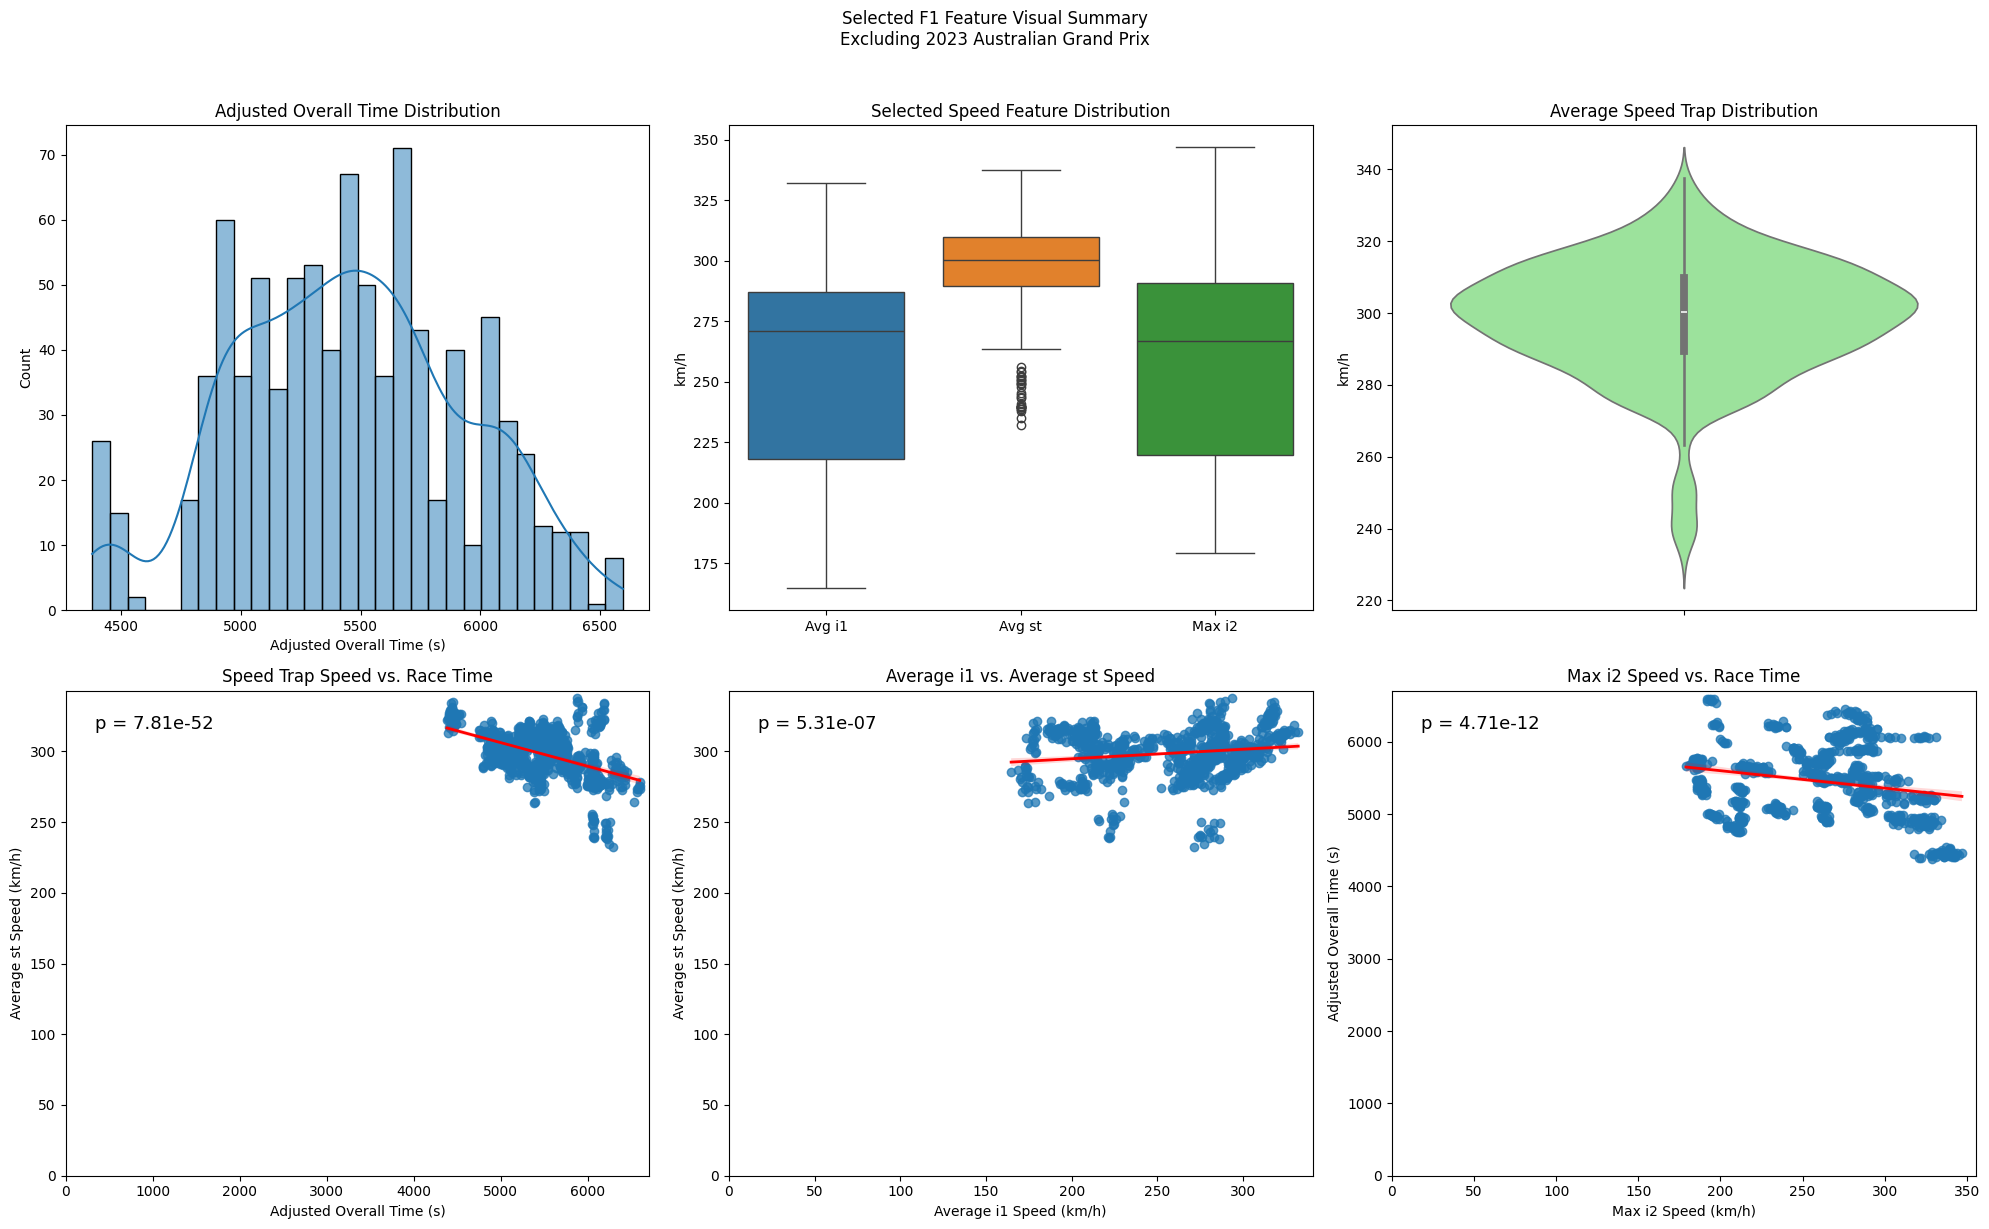

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

plot_df = selected_df.sort_values("Adjusted Overall Time (s)").reset_index(drop=True)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle(
    "Selected F1 Feature Visual Summary\nExcluding 2023 Australian Grand Prix",
    y=1.02,
)

# Histogram: distribution of adjusted race time
sns.histplot(plot_df["Adjusted Overall Time (s)"], bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Adjusted Overall Time Distribution")
axes[0, 0].set_xlabel("Adjusted Overall Time (s)")
axes[0, 0].set_ylabel("Count")

# Box plot: spread of the three selected speed features only
boxplot_df = plot_df[
    ["Average i1 Speed (km/h)", "Average st Speed (km/h)", "Max i2 Speed (km/h)"]
]
sns.boxplot(data=boxplot_df, orient="v", ax=axes[0, 1])
axes[0, 1].set_title("Selected Speed Feature Distribution")
axes[0, 1].set_ylabel("km/h")
axes[0, 1].set_xticklabels(["Avg i1", "Avg st", "Max i2"], rotation=0)

# Violin plot: distribution of speed trap speed
sns.violinplot(y=plot_df["Average st Speed (km/h)"], ax=axes[0, 2], color="lightgreen")
axes[0, 2].set_title("Average Speed Trap Distribution")
axes[0, 2].set_ylabel("km/h")

# Scatter plot: relationship between speed and overall race time
x_values = plot_df["Adjusted Overall Time (s)"]
y_values = plot_df["Average st Speed (km/h)"]
_, p_value = pearsonr(x_values, y_values)
ax = axes[1, 0]
sns.regplot(
    x=x_values,
    y=y_values,
    ax=ax,
    scatter_kws={"alpha": 0.75},
    line_kws={"color": "red", "linewidth": 2},
)
ax.set_title("Speed Trap Speed vs. Race Time")
ax.set_xlabel("Adjusted Overall Time (s)")
ax.set_ylabel("Average st Speed (km/h)")
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.text(
    0.05,
    0.95,
    f"p = {p_value:.3g}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=13,
)

# Scatter plot: comparison of intermediate 1 and speed trap speed
x_values = plot_df["Average i1 Speed (km/h)"]
y_values = plot_df["Average st Speed (km/h)"]
_, p_value = pearsonr(x_values, y_values)
ax = axes[1, 1]
sns.regplot(
    x=x_values,
    y=y_values,
    ax=ax,
    scatter_kws={"alpha": 0.75},
    line_kws={"color": "red", "linewidth": 2},
)
ax.set_title("Average i1 vs. Average st Speed")
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.text(
    0.05,
    0.95,
    f"p = {p_value:.3g}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=13,
)

# Scatter plot: comparison of max i2 speed and race time
x_values = plot_df["Max i2 Speed (km/h)"]
y_values = plot_df["Adjusted Overall Time (s)"]
_, p_value = pearsonr(x_values, y_values)
ax = axes[1, 2]
sns.regplot(
    x=x_values,
    y=y_values,
    ax=ax,
    scatter_kws={"alpha": 0.75},
    line_kws={"color": "red", "linewidth": 2},
)
ax.set_title("Max i2 Speed vs. Race Time")
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.text(
    0.05,
    0.95,
    f"p = {p_value:.3g}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=13,
)


plt.tight_layout()
plt.tight_layout()
plt.tight_layout()

plt.show()

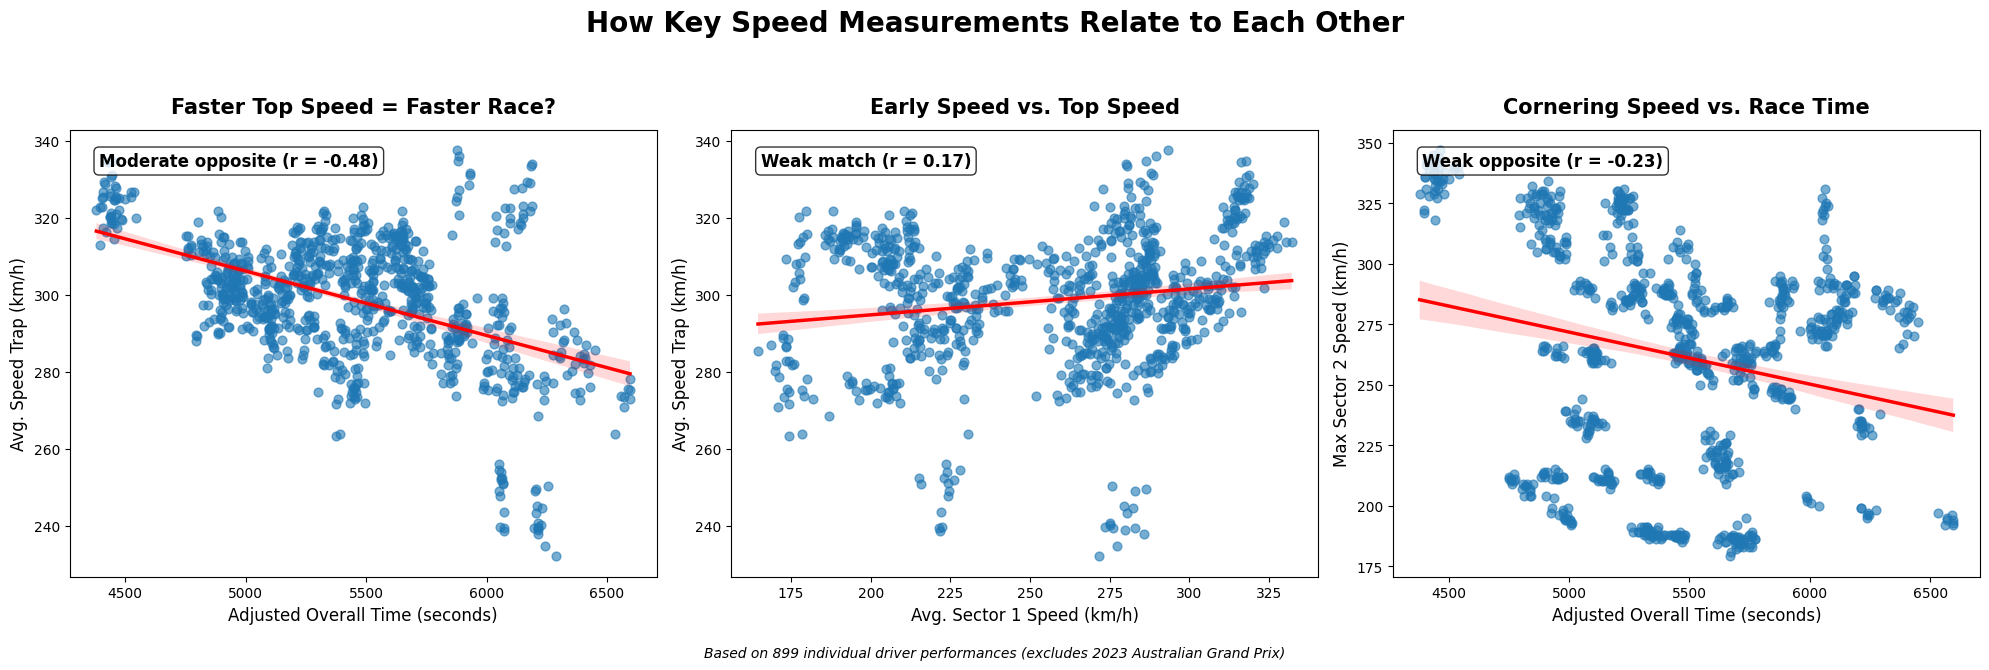

In [49]:
""" Creates the three key pair plots separately from the data above."""

plot_df = selected_df.sort_values("Adjusted Overall Time (s)").reset_index(drop=True)

# Plain-language labels and simple takeaways for a non-technical audience
friendly_names = {
    "Adjusted Overall Time (s)": "Adjusted Overall Time (seconds)",
    "Average st Speed (km/h)": "Avg. Speed Trap (km/h)",
    "Average i1 Speed (km/h)": "Avg. Sector 1 Speed (km/h)",
    "Max i2 Speed (km/h)": "Max Sector 2 Speed (km/h)",
}
plot_specs = [
    ("Adjusted Overall Time (s)", "Average st Speed (km/h)", "Faster Top Speed = Faster Race?"),
    ("Average i1 Speed (km/h)", "Average st Speed (km/h)", "Early Speed vs. Top Speed"),
    ("Adjusted Overall Time (s)", "Max i2 Speed (km/h)", "Cornering Speed vs. Race Time"),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(
    "How Key Speed Measurements Relate to Each Other",
    fontsize=20,
    fontweight="bold",
    y=1.05,
)

for ax, (x_column, y_column, title) in zip(axes, plot_specs):
    x_values = plot_df[x_column]
    y_values = plot_df[y_column]
    correlation, p_value = pearsonr(x_values, y_values)
    strength = "Strong" if abs(correlation) >= 0.5 else "Moderate" if abs(correlation) >= 0.3 else "Weak"
    direction = "match" if correlation > 0 else "opposite"

    sns.regplot(
        x=x_values,
        y=y_values,
        ax=ax,
        scatter_kws={"alpha": 0.6, "s": 40},
        line_kws={"color": "red", "linewidth": 2.5},
    )
    ax.set_title(title, fontsize=15, fontweight="bold", pad=12)
    ax.set_xlabel(friendly_names[x_column], fontsize=12)
    ax.set_ylabel(friendly_names[y_column], fontsize=12)
    ax.tick_params(labelsize=10)
    ax.text(
        0.05,
        0.95,
        f"{strength} {direction} (r = {correlation:.2f})",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=12,
        fontweight="bold",
        bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.8},
    )

fig.text(
    0.5, -0.03,
    f"Based on {len(plot_df)} individual driver performances (excludes 2023 Australian Grand Prix)",
    ha="center",
    fontsize=10,
    style="italic",
)
plt.tight_layout()
plt.show()